# CSE427 Final Code Notebook  
## Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text (SST) Compression

This notebook is the cleaned final code submission for the CSE427 SST project.

It preserves the required project work:
1. Exploratory data analysis (EDA)
2. Dataset preprocessing
3. Baseline model implementation
4. SST construction and filtering
5. Real GQA scene graph preprocessing
6. SST + Mistral reasoning experiments
7. Balanced 200-sample evaluation
8. Direct LLaVA image-based VLM baseline
9. SST vs LLaVA comparison
10. Error analysis

Important limitation: the SST branch uses GQA ground-truth scene graphs. Therefore, the SST experiments are an **oracle semantic-compression study**, not yet a fully automatic raw-image-to-SST pipeline.


## 0. Execution Notes

This notebook contains both reproducibility code and saved-result analysis code.

Some cells are computationally expensive:
- Full 200-sample SST + Mistral evaluation
- Full 200-sample LLaVA image baseline

Those cells are kept for documentation and reproducibility, but final result files are saved under `../outputs/results/`.
Do not rerun expensive cells unless you intentionally want to recompute the experiments.


## 1. Setup and Imports

This section configures project paths and imports the libraries used throughout the notebook.


In [1]:
# Cell 1.1: Configure project path and import core libraries
import sys
import os

project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

print("Project root:", project_root)
print("Added src path:", src_path)

#1 - imports 
import sys
import os
import json
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

print('Notebook setup complete')


Project root: /Users/alisha/Documents/CSE427_SST_Project
Added src path: /Users/alisha/Documents/CSE427_SST_Project/src
Notebook setup complete


## 2. Initial GQA Sample EDA

This section loads a small GQA-style sample dataset and performs initial exploratory data analysis.
It documents question type distribution and question length patterns, satisfying the EDA requirement.


In [2]:
# Cell 2.1: Load sample GQA-style question data
# 2 Add project root to path


#sys.path.append(os.path.abspath("src"))
sys.path.append(os.path.abspath("../src"))

# Import loader
from dataset.gqa_loader import load_gqa_questions

# Load sample data
file_path = "../data/raw/sample_questions.json"

records = load_gqa_questions(file_path)

print(f"Loaded {len(records)} records")
print(records[0])


Loaded 3 records
{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}}}


In [3]:
# Cell 2.2: Convert sample records to a DataFrame
# 3 Convert records to DataFrame for EDA


df = pd.DataFrame(records)

print(df.head())


  question_id image_id                     question answer  \
0          q1     img1       What color is the bus?    red   
1          q2     img2   How many people are there?      3   
2          q3     img3  Is the person near the car?    yes   

                       types  \
0  {'semantic': 'attribute'}   
1      {'semantic': 'count'}   
2   {'semantic': 'relation'}   

                                         full_record  
0  {'imageId': 'img1', 'question': 'What color is...  
1  {'imageId': 'img2', 'question': 'How many peop...  
2  {'imageId': 'img3', 'question': 'Is the person...  


In [4]:
# Cell 2.3: Extract semantic question types
# 4 Extract semantic type from nested dictionary
df["semantic_type"] = df["types"].apply(lambda x: x.get("semantic") if isinstance(x, dict) else None)

print(df[["question", "semantic_type"]])


                      question semantic_type
0       What color is the bus?     attribute
1   How many people are there?         count
2  Is the person near the car?      relation


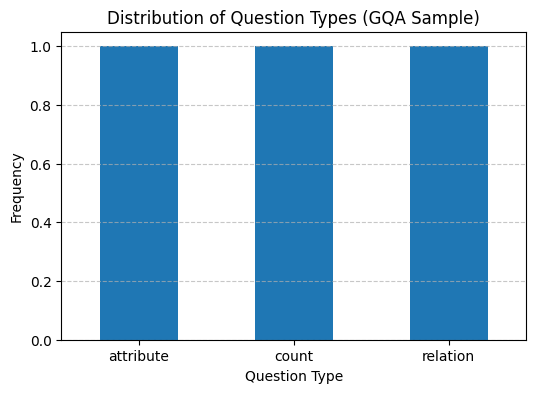

In [5]:
# Cell 2.4: Plot semantic type distribution
# 5 Improved visualization for report


type_counts = df["semantic_type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar")

plt.title("Distribution of Question Types (GQA Sample)", fontsize=12)
plt.xlabel("Question Type")
plt.ylabel("Frequency")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure for report
plt.savefig("../outputs/eda/question_type_distribution.png")

plt.show()


In [6]:
# Cell 2.5: Compute question lengths
# 6 Analyze question length
df["question_length"] = df["question"].apply(lambda x: len(x.split()))

print(df[["question", "question_length"]])


                      question  question_length
0       What color is the bus?                5
1   How many people are there?                5
2  Is the person near the car?                6


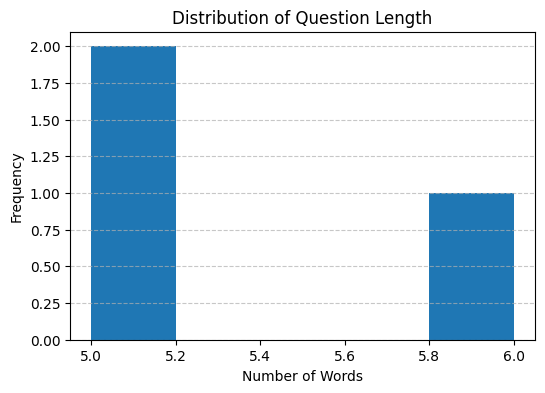

In [7]:
# Cell 2.6: Plot question length distribution
# 7 Plot question length distribution


plt.figure(figsize=(6,4))
plt.hist(df["question_length"], bins=5)

plt.title("Distribution of Question Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_distribution.png")

plt.show()


In [8]:
# Cell 2.7: Analyze average question length by semantic type
# 8 Analyze question length by semantic type
grouped = df.groupby("semantic_type")["question_length"].mean()

print(grouped)


semantic_type
attribute    5.0
count        5.0
relation     6.0
Name: question_length, dtype: float64


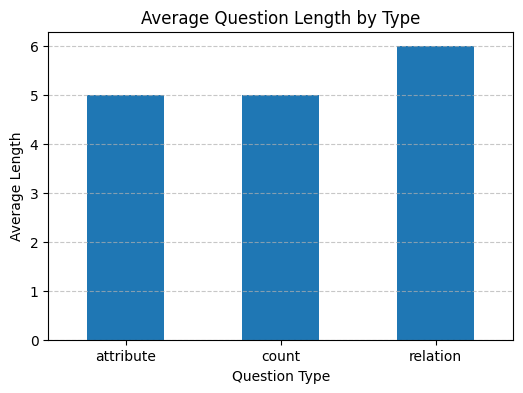

In [9]:
# Cell 2.8: Plot average question length by semantic type
# 9 Plot average question length per type


plt.figure(figsize=(6,4))
grouped.plot(kind="bar")

plt.title("Average Question Length by Type")
plt.xlabel("Question Type")
plt.ylabel("Average Length")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_by_type.png")

plt.show()


## 3. Text Preprocessing and Question-Only Baseline

This section performs basic text preprocessing and implements a simple Bag-of-Words + Logistic Regression baseline.
The baseline uses question text only and ignores image/SST information, so it serves as a sanity-check baseline for answer bias.


In [10]:
# Cell 3.1: Clean question text
# 10 Basic text preprocessing
import re
# Convert questions to lowercase
df["question_clean"] = df["question"].str.lower()

# Remove punctuation


def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["question_clean"] = df["question_clean"].apply(clean_text)

print(df[["question", "question_clean"]])


                      question              question_clean
0       What color is the bus?       what color is the bus
1   How many people are there?   how many people are there
2  Is the person near the car?  is the person near the car


In [11]:
# Cell 3.2: Prepare question text inputs and answer labels
# 11 Prepare inputs for modeling

X = df["question_clean"]   # input
y = df["answer"]           # target

print("Sample input:", X.iloc[0])
print("Sample label:", y.iloc[0])


Sample input: what color is the bus
Sample label: red


In [12]:
# Cell 3.3: Train and evaluate Bag-of-Words Logistic Regression baseline
#12 Baseline model with CountVectorizer and Logistic Regression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Make sure cleaned text exists
if "question_clean" not in df.columns:
    df["question_clean"] = df["question"].str.lower().str.strip()

# Convert text to numerical features
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(df["question_clean"])

y = df["answer"]

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_vec, y)

# Predict on the same data (sanity check only)
y_pred = model.predict(X_vec)

# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Baseline Logistic Regression Accuracy: {accuracy:.2f}")

# Show predictions
for i in range(X_vec.shape[0]):
    print(f"Q: {df['question_clean'].iloc[i]}")
    print(f"Actual: {y.iloc[i]} | Predicted: {y_pred[i]}")
    print("-" * 40)


Baseline Logistic Regression Accuracy: 1.00
Q: what color is the bus
Actual: red | Predicted: red
----------------------------------------
Q: how many people are there
Actual: 3 | Predicted: 3
----------------------------------------
Q: is the person near the car
Actual: yes | Predicted: yes
----------------------------------------


## 4. Toy SST Pipeline Validation

This section uses a tiny toy dataset to validate the SST representation, prompt serialization, question-aware filtering,
mock reasoning, and evaluation logic before moving to real GQA scene graphs.

These toy results are for debugging and should not be overclaimed.


In [13]:
# Cell 4.1: Test basic SST builder and serializer
# 13 Test the SST builder 

from serializer.sst_builder import build_sst, sst_to_prompt

sample_sst = build_sst(
    objects=["bus", "person", "stop_sign"],
    counts={"person": 3},
    attributes=["bus: red"],
    relations=["person near bus", "stop_sign right of bus"],
    text=["STOP"]
)

print(sample_sst)
print()
print(sst_to_prompt(sample_sst))


{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}

Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [14]:
# Cell 4.2: Load toy SST dataset
#14 loads toy SST dataset for testing
import json

with open("../data/processed/sample_questions_with_sst.json", "r") as f:
    records = json.load(f)

print(type(records))
print(len(records))
print(records["q1"])


<class 'dict'>
3
{'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [15]:
# Cell 4.3: Inspect one toy sample
#15 inspects toy sample 
sample = records["q1"]
print(sample["question"])
print(sample["answer"])
print(sample["types"]["semantic"])
print(sample["sst"])


What color is the bus?
red
attribute
{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}


In [16]:
# Cell 4.4: Load toy SST samples through project loader
#16 loads sst toy data
from dataset.gqa_loader import load_gqa_questions

data_with_sst = load_gqa_questions("../data/processed/sample_questions_with_sst.json")
print(data_with_sst[0])


{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [17]:
# Cell 4.5: Serialize SST into prompt text
#17 serializes SST prompt 
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

prompt_text = sst_to_prompt(sample["sst"])

print("QUESTION:")
print(sample["question"])

print("\nGROUND TRUTH ANSWER:")
print(sample["answer"])

print("\nSST PROMPT:")
print(prompt_text)


QUESTION:
What color is the bus?

GROUND TRUTH ANSWER:
red

SST PROMPT:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [18]:
# Cell 4.6: Print all toy SST samples
# 18 prints all samples with their SST prompts
for i, sample in enumerate(data_with_sst):
    print(f"\n--- Sample {i+1} ---")
    print("Question:", sample["question"])
    print("Semantic type:", sample["types"]["semantic"])
    print(sst_to_prompt(sample["sst"]))



--- Sample 1 ---
Question: What color is the bus?
Semantic type: attribute
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 2 ---
Question: How many people are there?
Semantic type: count
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 3 ---
Question: Is the person near the car?
Semantic type: relation
Scene-to-Structured-Text Representation:
Objects: person, car, tree
Counts: person: 1, car: 1
Attributes: car: blue
Relations: person near car, tree left of car
Text: None


In [19]:
# Cell 4.7: Demonstrate question-aware SST filtering
# 19 question-aware sst filtering example 
from filtering.question_aware_filter import filter_sst_by_question_type
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

semantic_type = sample["types"]["semantic"]

filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)

print("QUESTION TYPE:", semantic_type)

print("\nFULL SST:")
print(sst_to_prompt(sample["sst"]))

print("\nFILTERED SST:")
print(sst_to_prompt(filtered_sst))


QUESTION TYPE: attribute

FULL SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

FILTERED SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: None
Attributes: bus: red
Relations: None
Text: STOP


In [20]:
# Cell 4.8: Define mock rule-based SST reasoner
# 20 Mock reasoning function to simulate LLM behavior based on SST content
def mock_reasoning(sample):
    """
    Simple rule-based reasoning to simulate LLM behavior.
    This is NOT the final model — just for pipeline validation.
    """

    sst = sample["sst"]
    question = sample["question"].lower()

    # COUNT
    if "how many" in question:
        if sst["counts"]:
            return sst["counts"][0].split(":")[-1].strip()

    # ATTRIBUTE (color)
    if "color" in question:
        if sst["attributes"]:
            return sst["attributes"][0].split(":")[-1].strip()

    # RELATION (yes/no)
    if "near" in question or "left" in question or "right" in question:
        if sst["relations"]:
            return "yes"

    return "unknown"


In [21]:
# Cell 4.9: Test mock reasoner on toy samples
#21 Tests the mock reasoning function on all samples
for sample in data_with_sst:
    pred = mock_reasoning(sample)

    print("\nQUESTION:", sample["question"])
    print("GT:", sample["answer"])
    print("PRED:", pred)



QUESTION: What color is the bus?
GT: red
PRED: red

QUESTION: How many people are there?
GT: 3
PRED: 3

QUESTION: Is the person near the car?
GT: yes
PRED: yes


In [22]:
# Cell 4.10: Evaluate full vs filtered toy SST
#22 Evaluates the full pipeline with both full and filtered SSTs
def evaluate_pipeline(data):
    results = []

    for sample in data:
        question = sample["question"]
        answer = sample["answer"]
        semantic_type = sample["types"]["semantic"]

        # FULL SST
        full_prompt = sst_to_prompt(sample["sst"])
        full_pred = mock_reasoning(sample)
        full_tokens = len(full_prompt.split())
        full_correct = (full_pred == answer)

        # FILTERED SST
        filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)
        filtered_prompt = sst_to_prompt(filtered_sst)

        # simulate reasoning using filtered SST
        sample_filtered = sample.copy()
        sample_filtered["sst"] = filtered_sst

        filtered_pred = mock_reasoning(sample_filtered)
        filtered_tokens = len(filtered_prompt.split())
        filtered_correct = (filtered_pred == answer)

        results.append({
            "question": question,
            "full_tokens": full_tokens,
            "filtered_tokens": filtered_tokens,
            "full_correct": full_correct,
            "filtered_correct": filtered_correct
        })

    return results


In [23]:
# Cell 4.11: Print toy evaluation results
#22 Evaluates the full pipeline with both full and filtered SSTs
results = evaluate_pipeline(data_with_sst)

for r in results:
    print(r)


{'question': 'What color is the bus?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'How many people are there?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'Is the person near the car?', 'full_tokens': 24, 'filtered_tokens': 20, 'full_correct': True, 'filtered_correct': True}


In [24]:
# Cell 4.12: Summarize toy accuracy and token usage
# 23 Summarizes results
import numpy as np

full_acc = np.mean([r["full_correct"] for r in results])
filtered_acc = np.mean([r["filtered_correct"] for r in results])

avg_full_tokens = np.mean([r["full_tokens"] for r in results])
avg_filtered_tokens = np.mean([r["filtered_tokens"] for r in results])

print("FULL ACCURACY:", full_acc)
print("FILTERED ACCURACY:", filtered_acc)

print("\nAVG TOKENS (FULL):", avg_full_tokens)
print("AVG TOKENS (FILTERED):", avg_filtered_tokens)


FULL ACCURACY: 1.0
FILTERED ACCURACY: 1.0

AVG TOKENS (FULL): 22.666666666666668
AVG TOKENS (FILTERED): 16.666666666666668


In [25]:
# Cell 4.13: Convert toy results to DataFrame
#24 Create a DataFrame for better visualization of results
import pandas as pd

df = pd.DataFrame(results)
df


,question,full_tokens,filtered_tokens,full_correct,filtered_correct
0,What color is the bus?,22,15,True,True
1,How many people are there?,22,15,True,True
2,Is the person near the car?,24,20,True,True


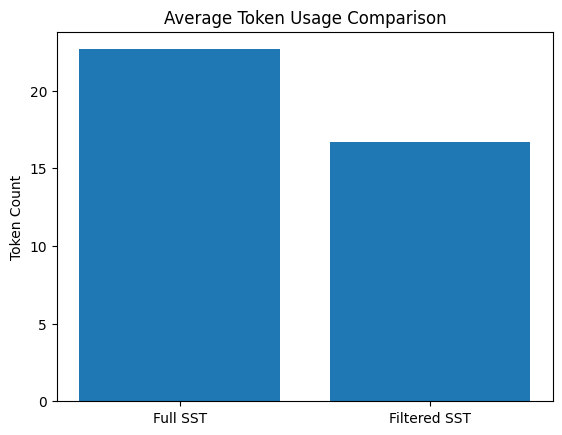

In [26]:
# Cell 4.14: Visualize toy token usage comparison
#25 Visualize token usage comparison
import matplotlib.pyplot as plt

labels = ["Full SST", "Filtered SST"]
tokens = [avg_full_tokens, avg_filtered_tokens]

plt.bar(labels, tokens)
plt.title("Average Token Usage Comparison")
plt.ylabel("Token Count")
plt.show()


## 5. Early Model Comparison on Toy SST Samples

This section implements multiple early pipelines:
1. Question-only baseline
2. Full SST
3. Question-aware filtered SST
4. Objects-only SST

This documents the baseline/model implementation requirement before the real GQA experiments.


In [27]:
# Cell 5.1: Define evaluation utilities
#26 Visualize accuracy comparison
#1: Utility functions

import time
import pandas as pd
import numpy as np
from collections import Counter


def normalize_answer(answer):
    """
    Normalize answer text before exact-match evaluation.
    """
    return str(answer).lower().strip()


def count_tokens_simple(text):
    """
    Simple whitespace token counter.

    This is not exact model tokenization, but it is acceptable for early
    comparison. Later this can be replaced with a model-specific tokenizer.
    """
    if text is None:
        return 0
    return len(str(text).split())


def safe_get_semantic_type(sample):
    """
    Safely extract semantic question type.
    """
    if "types" in sample and isinstance(sample["types"], dict):
        return sample["types"].get("semantic", "unknown")
    return "unknown"


def safe_sst_to_prompt(sst):
    """
    Converts SST to prompt text.
    Falls back to string conversion if the project serializer fails.
    """
    try:
        return sst_to_prompt(sst)
    except Exception:
        return str(sst)


In [28]:
# Cell 5.2: Validate and clean toy SST samples
#27: Preprocessing and schema validation
def validate_and_clean_sample(sample, idx):
    """
    Validates and cleans one sample.

    This is important because Week 4 requires checking whether preprocessing
    changes are needed before final evaluation.
    """

    cleaned = sample.copy()

    # Ensure ID exists
    cleaned["question_id"] = cleaned.get("question_id", f"sample_{idx+1}")

    # Normalize question and answer
    cleaned["question"] = str(cleaned.get("question", "")).strip()
    cleaned["answer"] = normalize_answer(cleaned.get("answer", ""))

    # Ensure semantic type exists
    if "types" not in cleaned or not isinstance(cleaned["types"], dict):
        cleaned["types"] = {"semantic": "unknown"}
    elif "semantic" not in cleaned["types"]:
        cleaned["types"]["semantic"] = "unknown"

    # Ensure SST exists
    if "sst" not in cleaned or not isinstance(cleaned["sst"], dict):
        cleaned["sst"] = {
            "objects": [],
            "counts": [],
            "attributes": [],
            "relations": [],
            "text": []
        }

    # Ensure all SST fields exist
    required_sst_fields = ["objects", "counts", "attributes", "relations", "text"]
    for field in required_sst_fields:
        if field not in cleaned["sst"]:
            cleaned["sst"][field] = []

    return cleaned


cleaned_data = [
    validate_and_clean_sample(sample, idx)
    for idx, sample in enumerate(data_with_sst)
]

print("Original samples:", len(data_with_sst))
print("Cleaned samples:", len(cleaned_data))
print("First cleaned sample:")
print(cleaned_data[0])


Original samples: 3
Cleaned samples: 3
First cleaned sample:
{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [29]:
# Cell 5.3: Define SST variants
#28: Define SST variant
def make_objects_only_sst(sst):
    """
    Keeps only object information.
    This is an ablation baseline.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": [],
        "attributes": [],
        "relations": [],
        "text": []
    }


def make_full_sst(sst):
    """
    Keeps the full SST unchanged.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": sst.get("attributes", []),
        "relations": sst.get("relations", []),
        "text": sst.get("text", [])
    }


def make_filtered_sst(sample):
    """
    Applies question-aware filtering based on semantic type.
    This is the proposed token-efficient version.
    """
    semantic_type = safe_get_semantic_type(sample)
    return filter_sst_by_question_type(sample["sst"], semantic_type)


In [30]:
# Cell 5.4: Define early model pipelines
#29: Define the 4 model pipelines
def predict_question_only(sample, train_answer_prior=None):
    """
    Question-only baseline.

    This model does not use SST at all.
    It predicts the most common answer from the dataset.

    Purpose:
    If this performs well, the dataset may contain answer bias.
    """

    if train_answer_prior is None:
        return "unknown"

    return train_answer_prior


def predict_with_sst_rule_reasoner(sample):
    """
    Rule-based SST reasoner.

    This uses the existing mock_reasoning function.
    It is used for controlled pipeline comparison.
    """

    return normalize_answer(mock_reasoning(sample))


def build_model_input(sample, pipeline_name, majority_answer):
    """
    Builds the input representation for each pipeline.
    """

    if pipeline_name == "question_only":
        prompt = sample["question"]
        model_sample = sample.copy()

    elif pipeline_name == "full_sst":
        full_sst = make_full_sst(sample["sst"])
        prompt = safe_sst_to_prompt(full_sst)
        model_sample = sample.copy()
        model_sample["sst"] = full_sst

    elif pipeline_name == "filtered_sst":
        filtered_sst = make_filtered_sst(sample)
        prompt = safe_sst_to_prompt(filtered_sst)
        model_sample = sample.copy()
        model_sample["sst"] = filtered_sst

    elif pipeline_name == "objects_only_sst":
        objects_only_sst = make_objects_only_sst(sample["sst"])
        prompt = safe_sst_to_prompt(objects_only_sst)
        model_sample = sample.copy()
        model_sample["sst"] = objects_only_sst

    else:
        raise ValueError(f"Unknown pipeline: {pipeline_name}")

    return prompt, model_sample


def run_pipeline_prediction(sample, pipeline_name, majority_answer):
    """
    Runs prediction for one sample using one pipeline.
    """

    prompt, model_sample = build_model_input(sample, pipeline_name, majority_answer)

    start_time = time.perf_counter()

    if pipeline_name == "question_only":
        prediction = predict_question_only(model_sample, majority_answer)
    else:
        prediction = predict_with_sst_rule_reasoner(model_sample)

    end_time = time.perf_counter()

    latency_ms = (end_time - start_time) * 1000

    return {
        "prediction": normalize_answer(prediction),
        "tokens": count_tokens_simple(prompt),
        "latency_ms": latency_ms,
        "prompt": prompt
    }


In [31]:
# Cell 5.5: Evaluate early model pipelines
#30: Evaluate all pipelines and compile results into a DataFrame
def evaluate_model_pipelines(data):
    """
    Evaluates all Week 4 model pipelines.

    Pipelines:
    1. question_only
    2. full_sst
    3. filtered_sst
    4. objects_only_sst
    """

    pipelines = [
        "question_only",
        "full_sst",
        "filtered_sst",
        "objects_only_sst"
    ]

    answer_counts = Counter([normalize_answer(sample["answer"]) for sample in data])
    majority_answer = answer_counts.most_common(1)[0][0]

    rows = []

    for sample in data:
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        for pipeline_name in pipelines:
            result = run_pipeline_prediction(
                sample=sample,
                pipeline_name=pipeline_name,
                majority_answer=majority_answer
            )

            prediction = result["prediction"]
            correct = int(prediction == true_answer)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": pipeline_name,
                "prediction": prediction,
                "correct": correct,
                "tokens": result["tokens"],
                "latency_ms": result["latency_ms"],
                "prompt": result["prompt"]
            })

    return pd.DataFrame(rows)


week4_results_df = evaluate_model_pipelines(cleaned_data)

week4_results_df.head()


,question_id,question,semantic_type,true_answer,pipeline,prediction,correct,tokens,latency_ms,prompt
0,q1,What color is the bus?,attribute,red,question_only,red,1,5,0.000500,What color is the bus?
1,q1,What color is the bus?,attribute,red,full_sst,red,1,22,0.002292,Scene-to-Structured-Text Representation:\nObje...
2,q1,What color is the bus?,attribute,red,filtered_sst,red,1,15,0.000917,Scene-to-Structured-Text Representation:\nObje...
3,q1,What color is the bus?,attribute,red,objects_only_sst,unknown,0,14,0.000709,Scene-to-Structured-Text Representation:\nObje...
4,q2,How many people are there?,count,3,question_only,red,0,5,0.000166,How many people are there?


In [32]:
# Cell 5.6: Summarize early model results
#31 summary table 
week4_summary_df = (
    week4_results_df
    .groupby("pipeline")
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

# Token reduction compared with Full SST
full_sst_avg_tokens = week4_summary_df.loc[
    week4_summary_df["pipeline"] == "full_sst",
    "average_tokens"
].values[0]

week4_summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_sst_avg_tokens - week4_summary_df["average_tokens"]) / full_sst_avg_tokens
) * 100

week4_summary_df = week4_summary_df.sort_values(
    by=["accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

week4_summary_df


,pipeline,accuracy,average_tokens,average_latency_ms,token_reduction_vs_full_sst_percent
0,filtered_sst,1.000000,16.666667,0.000667,26.470588
1,full_sst,1.000000,22.666667,0.001208,0.000000
3,question_only,0.333333,5.333333,0.000292,76.470588
2,objects_only_sst,0.000000,14.000000,0.000653,38.235294


In [33]:
# Cell 5.7: Analyze early results by semantic type
#32 evaluation by semantic type 
semantic_comparison_df = (
    week4_results_df
    .groupby(["semantic_type", "pipeline"])
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

semantic_comparison_df


,semantic_type,pipeline,accuracy,average_tokens,average_latency_ms
0,attribute,filtered_sst,1.0,15.0,0.000917
1,attribute,full_sst,1.0,22.0,0.002292
2,attribute,objects_only_sst,0.0,14.0,0.000709
3,attribute,question_only,1.0,5.0,0.000500
4,count,filtered_sst,1.0,15.0,0.000500
5,count,full_sst,1.0,22.0,0.000666
6,count,objects_only_sst,0.0,14.0,0.000791
7,count,question_only,0.0,5.0,0.000166
8,relation,filtered_sst,1.0,20.0,0.000583
9,relation,full_sst,1.0,24.0,0.000667


In [34]:
# Cell 5.8: Save early model comparison results
#33 Save results to CSV for reporting and further analysis
import os

os.makedirs("../outputs/results", exist_ok=True)

week4_results_df.to_csv("../outputs/results/week4_model_comparison_detailed.csv", index=False)
week4_summary_df.to_csv("../outputs/results/week4_model_comparison_summary.csv", index=False)
semantic_comparison_df.to_csv("../outputs/results/week4_semantic_type_comparison.csv", index=False)

print("Saved Week 4 result files:")
print("../outputs/results/week4_model_comparison_detailed.csv")
print("../outputs/results/week4_model_comparison_summary.csv")
print("../outputs/results/week4_semantic_type_comparison.csv")


Saved Week 4 result files:
../outputs/results/week4_model_comparison_detailed.csv
../outputs/results/week4_model_comparison_summary.csv
../outputs/results/week4_semantic_type_comparison.csv


## 6. Local Mistral Reasoning over SST

This section uses local Mistral through Ollama for SST-based reasoning.
It replaces the mock rule-based reasoner with an actual local LLM.

Environment note:
- Ollama should be installed locally.
- Mistral should be pulled once with: `ollama pull mistral`


In [35]:
# Cell 6.1: Confirm Ollama Python package import
#34 Test Ollama package import
import ollama

print("Ollama Python package ready.")


Ollama Python package ready.


In [36]:
# Cell 6.2: Smoke-test local Mistral on a tiny SST prompt
#35 Test a simple prompt with the Ollama package
import ollama
import time

test_prompt = """
Answer with one word only.

Scene:
Objects: bus, person
Attributes: bus: red

Question:
What color is the bus?

Answer:
""".strip()

start_time = time.perf_counter()

response = ollama.chat(
    model="mistral",
    messages=[
        {"role": "user", "content": test_prompt}
    ],
    options={
        "temperature": 0,
        "num_predict": 20
    }
)

end_time = time.perf_counter()

print("Raw response:")
print(response)

print("\nAnswer:")
print(response["message"]["content"].strip().lower())

print("\nLatency ms:")
print((end_time - start_time) * 1000)


Raw response:
model='mistral' created_at='2026-05-01T09:22:05.978401Z' done=True done_reason='stop' total_duration=3259645125 load_duration=2660944958 prompt_eval_count=42 prompt_eval_duration=537222667 eval_count=2 eval_duration=56267000 message=Message(role='assistant', content=' Red', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None

Answer:
red

Latency ms:
3264.585334000003


In [37]:
# Cell 6.3: Define Ollama reasoning and LLM prompt helpers
#36 Define a function to use Ollama for SST-based reasoning
def ollama_reasoning(prompt, model="mistral"):
    """
    Uses local Ollama model for SST-based reasoning.
    This replaces paid API-based reasoning.
    """

    start_time = time.perf_counter()

    response = ollama.chat(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        options={
            "temperature": 0,
            "num_predict": 20
        }
    )

    end_time = time.perf_counter()

    answer = response["message"]["content"].strip().lower()
    latency_ms = (end_time - start_time) * 1000

    return answer, latency_ms


def build_llm_reasoning_prompt(question, sst_prompt):
    """
    Build a short-answer reasoning prompt for local Mistral.
    This prompt is reused by the SST + Mistral evaluation cells.
    """
    return f"""
You are answering a visual question using only the structured scene information below.

Structured scene:
{sst_prompt}

Question:
{question}

Rules:
- Answer using only the structured scene information.
- Give only the final answer.
- Do not explain.
- If the answer is not available, answer unknown.

Final answer:
""".strip()


In [38]:
# Cell 6.4: Test SST + Mistral reasoning on one toy sample
#37 Test the full pipeline with Ollama reasoning on one sample
sample = cleaned_data[0]

question = sample["question"]
true_answer = sample["answer"]

full_sst = make_full_sst(sample["sst"])
full_sst_prompt = safe_sst_to_prompt(full_sst)

ollama_prompt = build_llm_reasoning_prompt(question, full_sst_prompt)

pred_answer, latency_ms = ollama_reasoning(ollama_prompt)

print("Question:", question)
print("Ground Truth:", true_answer)
print("Prediction:", pred_answer)
print("Correct:", pred_answer == true_answer)
print("Latency ms:", latency_ms)


Question: What color is the bus?
Ground Truth: red
Prediction: red
Correct: True
Latency ms: 1262.3081670008105


In [39]:
# Cell 6.5: Define toy SST + Mistral evaluation
#38 Evaluate all pipelines with Ollama reasoning

def evaluate_ollama_sst_pipelines(data, model="mistral"):
    """
    Evaluates local Mistral reasoning on multiple SST variants.

    Pipelines:
    1. full_sst_mistral
    2. filtered_sst_mistral
    3. objects_only_sst_mistral
    """

    pipelines = [
        "full_sst_mistral",
        "filtered_sst_mistral",
        "objects_only_sst_mistral"
    ]

    rows = []

    for sample in data:
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        for pipeline in pipelines:

            if pipeline == "full_sst_mistral":
                sst_variant = make_full_sst(sample["sst"])

            elif pipeline == "filtered_sst_mistral":
                sst_variant = make_filtered_sst(sample)

            elif pipeline == "objects_only_sst_mistral":
                sst_variant = make_objects_only_sst(sample["sst"])

            sst_prompt = safe_sst_to_prompt(sst_variant)
            reasoning_prompt = build_llm_reasoning_prompt(question, sst_prompt)

            pred_answer, latency_ms = ollama_reasoning(
                reasoning_prompt,
                model=model
            )

            pred_answer = normalize_answer(pred_answer)
            correct = int(pred_answer == true_answer)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": pipeline,
                "prediction": pred_answer,
                "correct": correct,
                "tokens": count_tokens_simple(reasoning_prompt),
                "latency_ms": latency_ms,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": reasoning_prompt
            })

            print(
                f"{pipeline} | Q: {question} | GT: {true_answer} | "
                f"Pred: {pred_answer} | Correct: {correct}"
            )

    return pd.DataFrame(rows)


In [40]:
# Cell 6.6: Run toy SST + Mistral evaluation
mistral_results_df = evaluate_ollama_sst_pipelines(cleaned_data, model="mistral")

mistral_results_df


full_sst_mistral | Q: What color is the bus? | GT: red | Pred: red | Correct: 1
filtered_sst_mistral | Q: What color is the bus? | GT: red | Pred: red | Correct: 1
objects_only_sst_mistral | Q: What color is the bus? | GT: red | Pred: unknown | Correct: 0
full_sst_mistral | Q: How many people are there? | GT: 3 | Pred: 3 | Correct: 1
filtered_sst_mistral | Q: How many people are there? | GT: 3 | Pred: 3 | Correct: 1
objects_only_sst_mistral | Q: How many people are there? | GT: 3 | Pred: unknown | Correct: 0
full_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: yes | Correct: 1
filtered_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: yes | Correct: 1
objects_only_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: unknown | Correct: 0


,question_id,question,semantic_type,true_answer,pipeline,prediction,correct,tokens,latency_ms,sst_prompt,reasoning_prompt
0,q1,What color is the bus?,attribute,red,full_sst_mistral,red,1,73,184.607917,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
1,q1,What color is the bus?,attribute,red,filtered_sst_mistral,red,1,66,766.667083,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
2,q1,What color is the bus?,attribute,red,objects_only_sst_mistral,unknown,0,65,836.374583,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
3,q2,How many people are there?,count,3,full_sst_mistral,3,1,73,842.934542,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
4,q2,How many people are there?,count,3,filtered_sst_mistral,3,1,66,791.273208,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
5,q2,How many people are there?,count,3,objects_only_sst_mistral,unknown,0,65,790.572791,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
6,q3,Is the person near the car?,relation,yes,full_sst_mistral,yes,1,76,956.009083,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
7,q3,Is the person near the car?,relation,yes,filtered_sst_mistral,yes,1,72,741.868958,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...
8,q3,Is the person near the car?,relation,yes,objects_only_sst_mistral,unknown,0,66,578.534750,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual question using only...


In [41]:
# Cell 6.7: Summarize toy Mistral results
#39 Summarize Ollama Mistral results
mistral_summary_df = (
    mistral_results_df
    .groupby("pipeline")
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_sst_tokens = mistral_summary_df.loc[
    mistral_summary_df["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

mistral_summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_sst_tokens - mistral_summary_df["average_tokens"]) / full_sst_tokens
) * 100

mistral_summary_df = mistral_summary_df.sort_values(
    by=["accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

mistral_summary_df


,pipeline,accuracy,average_tokens,average_latency_ms,token_reduction_vs_full_sst_percent
0,filtered_sst_mistral,1.0,68.000000,766.603083,8.108108
1,full_sst_mistral,1.0,74.000000,661.183847,0.000000
2,objects_only_sst_mistral,0.0,65.333333,735.160708,11.711712


In [42]:
# Cell 6.8: Save toy Mistral result files
#40 Save Mistral SST results to CSV
import os

os.makedirs("../outputs/results", exist_ok=True)

mistral_results_df.to_csv("../outputs/results/mistral_sst_detailed_results.csv", index=False)
mistral_summary_df.to_csv("../outputs/results/mistral_sst_summary_results.csv", index=False)

print("Saved Mistral SST results.")


Saved Mistral SST results.


## 7. Real GQA Scene Graph Preprocessing

This section moves from toy examples to real GQA validation scene graphs.
It converts GQA scene graphs into SST representations with objects, counts, attributes, relations, and text fields.


In [43]:
# Cell 7.1: Load real GQA validation scene graphs
# Additional EDA on scene graphs
import json
import os

val_scene_path = "../data/gqa_raw/val_sceneGraphs.json"

with open(val_scene_path, "r") as f:
    val_scene_graphs = json.load(f)

print("Number of validation scene graphs:", len(val_scene_graphs))

first_image_id = list(val_scene_graphs.keys())[0]
first_scene = val_scene_graphs[first_image_id]

print("First image id:", first_image_id)
print("Scene keys:", first_scene.keys())

print("\nFirst scene sample:")
first_scene


Number of validation scene graphs: 10696
First image id: 2353884
Scene keys: dict_keys(['width', 'objects', 'height'])

First scene sample:


{'width': 500,
 'objects': {'2716708': {'name': 'nose',
   'h': 9,
   'relations': [{'object': '2449847', 'name': 'of'},
    {'object': '2493560', 'name': 'to the right of'},
    {'object': '2370325', 'name': 'to the left of'}],
   'w': 7,
   'attributes': [],
   'y': 54,
   'x': 370},
  '2370325': {'name': 'eyes',
   'h': 4,
   'relations': [{'object': '2493560', 'name': 'to the right of'},
    {'object': '2716708', 'name': 'to the right of'},
    {'object': '2449847', 'name': 'of'}],
   'w': 6,
   'attributes': [],
   'y': 53,
   'x': 379},
  '2747168': {'name': 'sign',
   'h': 52,
   'relations': [{'object': '2449847', 'name': 'to the right of'}],
   'w': 96,
   'attributes': ['blue'],
   'y': 124,
   'x': 371},
  '3576182': {'name': 'air',
   'h': 194,
   'relations': [],
   'w': 492,
   'attributes': [],
   'y': 1,
   'x': 2},
  '3100523': {'name': 'ear',
   'h': 12,
   'relations': [{'object': '2449847', 'name': 'of'},
    {'object': '2493560', 'name': 'to the right of'}],
   'w'

In [44]:
# Cell 7.2: Convert a GQA scene graph into SST
#41 Convert GQA scene graph to SST format
from collections import Counter

def gqa_scene_to_sst(scene, max_objects=20, max_relations=30):
    """
    Converts one real GQA scene graph into our SST format.

    Input:
    - scene: one image scene graph from GQA

    Output:
    - SST dictionary with objects, counts, attributes, relations, text

    Notes:
    - GQA scene graphs already contain objects, attributes, and relations.
    - We limit objects and relations to keep prompts compact.
    """

    objects_dict = scene.get("objects", {})

    object_names = []
    attributes = []
    relations = []

    # Map object IDs to object names
    id_to_name = {}

    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")
        id_to_name[obj_id] = obj_name
        object_names.append(obj_name)

    # Counts
    counts_counter = Counter(object_names)
    counts = [
        f"{name}: {count}"
        for name, count in counts_counter.items()
        if count > 1
    ]

    # Attributes
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")
        obj_attributes = obj_data.get("attributes", [])

        for attr in obj_attributes:
            attributes.append(f"{obj_name}: {attr}")

    # Relations
    for obj_id, obj_data in objects_dict.items():
        subject_name = obj_data.get("name", "unknown")
        obj_relations = obj_data.get("relations", [])

        for rel in obj_relations:
            relation_name = rel.get("name", "")
            target_id = rel.get("object", "")
            target_name = id_to_name.get(target_id, "unknown")

            if relation_name and target_name != "unknown":
                relations.append(f"{subject_name} {relation_name} {target_name}")

    # Remove duplicates while keeping order
    object_names = list(dict.fromkeys(object_names))
    attributes = list(dict.fromkeys(attributes))
    relations = list(dict.fromkeys(relations))

    # Limit size for token efficiency
    object_names = object_names[:max_objects]
    attributes = attributes[:max_objects]
    relations = relations[:max_relations]

    sst = {
        "objects": object_names,
        "counts": counts,
        "attributes": attributes,
        "relations": relations,
        "text": []
    }

    return sst


In [45]:
# Cell 7.3: Test scene graph to SST conversion
# Test the conversion on the first scene graph
real_sst = gqa_scene_to_sst(first_scene)

print("Real SST from first GQA scene:")
print(real_sst)

print("\nSerialized SST:")
print(safe_sst_to_prompt(real_sst))


Real SST from first GQA scene:
{'objects': ['nose', 'eyes', 'sign', 'air', 'ear', 'socks', 'audience', 'tent', 'man', 'woman', 'shorts', 'shoe', 'roof', 'foot', 'logo', 'frisbee'], 'counts': ['man: 2', 'shoe: 2'], 'attributes': ['sign: blue', 'socks: white', 'shorts: gray', 'roof: white', 'logo: black', 'frisbee: yellow'], 'relations': ['nose of man', 'nose to the right of roof', 'nose to the left of eyes', 'eyes to the right of roof', 'eyes to the right of nose', 'eyes of man', 'sign to the right of man', 'ear of man', 'ear to the right of roof', 'socks to the left of shorts', 'man wearing socks', 'man wearing shorts', 'man to the left of sign', 'man to the right of man', 'man to the right of frisbee', 'woman to the left of shorts', 'shorts to the right of shoe', 'shorts to the right of woman', 'shorts to the right of foot', 'shorts to the right of socks', 'shoe of man', 'shoe to the left of shorts', 'roof to the left of logo', 'roof to the left of eyes', 'roof to the left of nose', '

In [46]:
# Cell 7.4: Define cleaning rules for noisy scene graph elements
#42 Define low-value objects and relations for filtering
LOW_VALUE_OBJECTS = {
    "nose", "eyes", "eye", "ear", "mouth", "hair", "head",
    "hand", "hands", "arm", "arms", "leg", "legs", "foot", "feet",
    "finger", "fingers", "face", "neck"
}

LOW_VALUE_RELATIONS = {
    "of"
}


def gqa_scene_to_clean_sst(scene, max_objects=15, max_attributes=20, max_relations=25):
    """
    Converts a GQA scene graph into a cleaner SST representation.

    This version removes low-value body-part objects and weak relations.
    The goal is to keep the SST compact and more useful for reasoning.
    """

    objects_dict = scene.get("objects", {})

    object_names = []
    attributes = []
    relations = []
    id_to_name = {}

    # First pass: collect useful objects
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")

        if obj_name in LOW_VALUE_OBJECTS:
            continue

        id_to_name[obj_id] = obj_name
        object_names.append(obj_name)

    # Counts
    counts_counter = Counter(object_names)
    counts = [
        f"{name}: {count}"
        for name, count in counts_counter.items()
        if count > 1
    ]

    # Attributes
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")

        if obj_name not in id_to_name.values():
            continue

        obj_attributes = obj_data.get("attributes", [])

        for attr in obj_attributes:
            attributes.append(f"{obj_name}: {attr}")

    # Relations
    for obj_id, obj_data in objects_dict.items():
        subject_name = obj_data.get("name", "unknown")

        if subject_name in LOW_VALUE_OBJECTS:
            continue

        obj_relations = obj_data.get("relations", [])

        for rel in obj_relations:
            relation_name = rel.get("name", "")
            target_id = rel.get("object", "")
            target_name = id_to_name.get(target_id, "unknown")

            if relation_name in LOW_VALUE_RELATIONS:
                continue

            if relation_name and target_name != "unknown":
                relations.append(f"{subject_name} {relation_name} {target_name}")

    # Remove duplicates while preserving order
    object_names = list(dict.fromkeys(object_names))
    attributes = list(dict.fromkeys(attributes))
    relations = list(dict.fromkeys(relations))

    return {
        "objects": object_names[:max_objects],
        "counts": counts[:max_objects],
        "attributes": attributes[:max_attributes],
        "relations": relations[:max_relations],
        "text": []
    }


In [47]:
# Cell 7.5: Test cleaned SST conversion
clean_real_sst = gqa_scene_to_clean_sst(first_scene)

print("Cleaned SST:")
print(safe_sst_to_prompt(clean_real_sst))

print("\nToken count:")
print(count_tokens_simple(safe_sst_to_prompt(clean_real_sst)))


Cleaned SST:
Scene-to-Structured-Text Representation:
Objects: sign, air, socks, audience, tent, man, woman, shorts, shoe, roof, logo, frisbee
Counts: man: 2, shoe: 2
Attributes: sign: blue, socks: white, shorts: gray, roof: white, logo: black, frisbee: yellow
Relations: sign to the right of man, socks to the left of shorts, man wearing socks, man wearing shorts, man to the left of sign, man to the right of man, man to the right of frisbee, woman to the left of shorts, shorts to the right of shoe, shorts to the right of woman, shorts to the right of socks, shoe to the left of shorts, roof to the left of logo, man to the left of man, logo to the right of roof, frisbee to the left of man
Text: None

Token count:
126


In [48]:
# Cell 7.6: Load real GQA validation questions
#43 Analyze the distribution of objects and relations in the validation set
import json

val_questions_path = "../data/gqa_raw/questions/val_balanced_questions.json"

with open(val_questions_path, "r") as f:
    val_questions = json.load(f)

print("Number of validation questions:", len(val_questions))

first_question_id = list(val_questions.keys())[0]
first_question = val_questions[first_question_id]

print("First question id:", first_question_id)
print("Question keys:", first_question.keys())

print("\nFirst question sample:")
first_question


Number of validation questions: 132062
First question id: 05515938
Question keys: dict_keys(['semantic', 'entailed', 'equivalent', 'question', 'imageId', 'isBalanced', 'groups', 'answer', 'semanticStr', 'annotations', 'types', 'fullAnswer'])

First question sample:


{'semantic': [{'operation': 'select',
   'dependencies': [],
   'argument': 'bird (329774)'},
  {'operation': 'query', 'dependencies': [0], 'argument': 'name'}],
 'entailed': ['05515937', '05515936', '05515922', '05515921'],
 'equivalent': ['05515938'],
 'question': 'What is this bird called?',
 'imageId': '2405722',
 'isBalanced': True,
 'groups': {'global': 'bird', 'local': '11q-bird'},
 'answer': 'parrot',
 'semanticStr': 'select: bird (329774)->query: name [0]',
 'annotations': {'answer': {'0': '329774'},
  'question': {'3': '329774'},
  'fullAnswer': {'3': '329774'}},
 'types': {'detailed': 'categoryThis',
  'semantic': 'cat',
  'structural': 'query'},
 'fullAnswer': 'This is a parrot.'}

In [49]:
# Cell 7.7: Join questions with scene graphs to build real SST samples
#44 Build a real GQA SST dataset by joining questions with scene graphs
def build_real_gqa_sst_dataset(
    questions,
    scene_graphs,
    max_samples=50,
    allowed_semantic_types=None
):
    """
    Builds a real GQA SST dataset by joining questions with scene graphs.

    Each sample contains:
    - question_id
    - image_id
    - question
    - answer
    - semantic type
    - clean SST built from real GQA scene graph
    """

    samples = []

    for question_id, q_data in questions.items():
        image_id = q_data.get("imageId")

        if image_id not in scene_graphs:
            continue

        semantic_type = q_data.get("types", {}).get("semantic", "unknown")

        if allowed_semantic_types is not None:
            if semantic_type not in allowed_semantic_types:
                continue

        scene = scene_graphs[image_id]
        sst = gqa_scene_to_clean_sst(scene)

        sample = {
            "question_id": question_id,
            "image_id": image_id,
            "question": q_data.get("question", ""),
            "answer": normalize_answer(q_data.get("answer", "")),
            "types": q_data.get("types", {}),
            "semantic_program": q_data.get("semantic", []),
            "semanticStr": q_data.get("semanticStr", ""),
            "sst": sst
        }

        samples.append(sample)

        if len(samples) >= max_samples:
            break

    return samples


real_gqa_samples = build_real_gqa_sst_dataset(
    questions=val_questions,
    scene_graphs=val_scene_graphs,
    max_samples=50,
    allowed_semantic_types=None
)

print("Real GQA SST samples:", len(real_gqa_samples))
print(real_gqa_samples[0])


Real GQA SST samples: 50
{'question_id': '05515938', 'image_id': '2405722', 'question': 'What is this bird called?', 'answer': 'parrot', 'types': {'detailed': 'categoryThis', 'semantic': 'cat', 'structural': 'query'}, 'semantic_program': [{'operation': 'select', 'dependencies': [], 'argument': 'bird (329774)'}, {'operation': 'query', 'dependencies': [0], 'argument': 'name'}], 'semanticStr': 'select: bird (329774)->query: name [0]', 'sst': {'objects': ['palm tree', 'leaves', 'bushes', 'feathers', 'fence', 'stone', 'wall', 'ladder', 'beak', 'parrot', 'clouds', 'sky', 'hillside', 'straw', 'rock'], 'counts': ['palm tree: 5', 'leaves: 2', 'bushes: 2', 'stone: 3', 'wall: 2', 'rock: 2'], 'attributes': ['leaves: green', 'bushes: tropical', 'feathers: white', 'feathers: ruffled', 'fence: silver', 'fence: chain-link', 'wall: stone', 'wall: rock', 'ladder: blue', 'ladder: metal', 'palm tree: tall', 'palm tree: green', 'beak: sharp', 'beak: curved', 'beak: black', 'beak: open', 'beak: pointy', 'pa

In [50]:
# Cell 7.8: Save real 50-sample SST dataset
import json
import os

os.makedirs("../data/processed", exist_ok=True)

real_gqa_output_path = "../data/processed/real_gqa_sst_50.json"

with open(real_gqa_output_path, "w") as f:
    json.dump(real_gqa_samples, f, indent=2)

print("Saved real GQA SST dataset:")
print(real_gqa_output_path)


Saved real GQA SST dataset:
../data/processed/real_gqa_sst_50.json


In [51]:
# Cell 7.9: Verify saved real SST dataset
with open("../data/processed/real_gqa_sst_50.json", "r") as f:
    check_real_gqa_samples = json.load(f)

print("Loaded samples:", len(check_real_gqa_samples))
print("First question:", check_real_gqa_samples[0]["question"])
print("First answer:", check_real_gqa_samples[0]["answer"])
print("First semantic type:", check_real_gqa_samples[0]["types"]["semantic"])
print("First SST:")
print(safe_sst_to_prompt(check_real_gqa_samples[0]["sst"]))


Loaded samples: 50
First question: What is this bird called?
First answer: parrot
First semantic type: cat
First SST:
Scene-to-Structured-Text Representation:
Objects: palm tree, leaves, bushes, feathers, fence, stone, wall, ladder, beak, parrot, clouds, sky, hillside, straw, rock
Counts: palm tree: 5, leaves: 2, bushes: 2, stone: 3, wall: 2, rock: 2
Attributes: leaves: green, bushes: tropical, feathers: white, feathers: ruffled, fence: silver, fence: chain-link, wall: stone, wall: rock, ladder: blue, ladder: metal, palm tree: tall, palm tree: green, beak: sharp, beak: curved, beak: black, beak: open, beak: pointy, parrot: white, clouds: small, clouds: white
Relations: palm tree behind parrot, palm tree on top of hillside, palm tree to the left of leaves, palm tree to the right of feathers, palm tree to the left of bushes, palm tree to the right of parrot, leaves to the right of parrot, bushes to the right of bushes, bushes near straw, bushes to the right of palm tree, feathers to the 

## 8. Real GQA 50-Sample SST Pilot

This section evaluates SST + Mistral methods on 50 real GQA validation examples.
It validates the real-data pipeline before scaling to the balanced 200-sample experiment.


In [52]:
# Cell 8.1: Redefine robust helpers for real GQA + Mistral evaluation
# Setup cell: re-define all helper functions needed for real GQA + Mistral evaluation

import os
import json
import time
import re
import pandas as pd
import numpy as np

try:
    import ollama
    print("Ollama package loaded.")
except Exception as e:
    print("Ollama import failed:", e)

# Try to import your project serializer/filter if available
try:
    from serializer.sst_builder import sst_to_prompt
    print("Imported sst_to_prompt from project files.")
except Exception:
    sst_to_prompt = None
    print("Could not import sst_to_prompt. Using fallback serializer.")

try:
    from filtering.question_aware_filter import filter_sst_by_question_type
    print("Imported filter_sst_by_question_type from project files.")
except Exception:
    filter_sst_by_question_type = None
    print("Could not import filter_sst_by_question_type. Using fallback filter.")


def normalize_answer(answer):
    """
    Normalize answers for exact-match evaluation.
    Keeps this simple but removes common formatting noise from LLM outputs.
    """
    answer = str(answer).lower().strip()
    answer = answer.replace("answer:", "").strip()
    answer = answer.strip(" .,!?:;\"'")
    return answer


def count_tokens_simple(text):
    """
    Simple whitespace-based token counter.
    """
    if text is None:
        return 0
    return len(str(text).split())


def safe_get_semantic_type(sample):
    """
    Safely extract GQA semantic type.
    """
    if "types" in sample and isinstance(sample["types"], dict):
        return sample["types"].get("semantic", "unknown")
    return "unknown"


def fallback_sst_to_prompt(sst):
    """
    Fallback SST serializer if project serializer is unavailable.
    """
    lines = []
    lines.append("Objects: " + ", ".join(map(str, sst.get("objects", []))))
    lines.append("Counts: " + ", ".join(map(str, sst.get("counts", []))))
    lines.append("Attributes: " + ", ".join(map(str, sst.get("attributes", []))))
    lines.append("Relations: " + ", ".join(map(str, sst.get("relations", []))))
    lines.append("Text: " + ", ".join(map(str, sst.get("text", []))))
    return "\n".join(lines)


def safe_sst_to_prompt(sst):
    """
    Convert SST dictionary into text.
    """
    if sst_to_prompt is not None:
        try:
            return sst_to_prompt(sst)
        except Exception:
            return fallback_sst_to_prompt(sst)
    return fallback_sst_to_prompt(sst)


def validate_and_clean_sample(sample, idx):
    """
    Validate and clean one real GQA sample.
    """
    cleaned = sample.copy()

    cleaned["question_id"] = cleaned.get("question_id", f"sample_{idx+1}")
    cleaned["question"] = str(cleaned.get("question", "")).strip()
    cleaned["answer"] = normalize_answer(cleaned.get("answer", ""))

    if "types" not in cleaned or not isinstance(cleaned["types"], dict):
        cleaned["types"] = {"semantic": "unknown"}
    elif "semantic" not in cleaned["types"]:
        cleaned["types"]["semantic"] = "unknown"

    if "sst" not in cleaned or not isinstance(cleaned["sst"], dict):
        cleaned["sst"] = {}

    for field in ["objects", "counts", "attributes", "relations", "text"]:
        if field not in cleaned["sst"]:
            cleaned["sst"][field] = []

    return cleaned


def make_full_sst(sst):
    """
    Full SST variant.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": sst.get("attributes", []),
        "relations": sst.get("relations", []),
        "text": sst.get("text", [])
    }


def make_objects_only_sst(sst):
    """
    Objects-only ablation.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": [],
        "attributes": [],
        "relations": [],
        "text": []
    }


def fallback_filter_sst_by_question_type(sst, semantic_type):
    """
    Basic fallback question-aware filtering.
    This is not final, but enough to continue the experiment.
    """
    semantic_type = str(semantic_type).lower()

    if semantic_type in ["count"]:
        return {
            "objects": sst.get("objects", []),
            "counts": sst.get("counts", []),
            "attributes": [],
            "relations": [],
            "text": []
        }

    elif semantic_type in ["rel", "relation", "verify", "exist", "logical"]:
        return {
            "objects": sst.get("objects", []),
            "counts": sst.get("counts", []),
            "attributes": sst.get("attributes", []),
            "relations": sst.get("relations", []),
            "text": sst.get("text", [])
        }

    elif semantic_type in ["query", "cat", "choose", "compare"]:
        return {
            "objects": sst.get("objects", []),
            "counts": sst.get("counts", []),
            "attributes": sst.get("attributes", []),
            "relations": [],
            "text": sst.get("text", [])
        }

    else:
        return make_full_sst(sst)


def make_filtered_sst(sample):
    """
    Filtered SST variant.
    """
    semantic_type = safe_get_semantic_type(sample)

    if filter_sst_by_question_type is not None:
        try:
            return filter_sst_by_question_type(sample["sst"], semantic_type)
        except Exception:
            return fallback_filter_sst_by_question_type(sample["sst"], semantic_type)

    return fallback_filter_sst_by_question_type(sample["sst"], semantic_type)


def build_llm_reasoning_prompt(question, sst_prompt):
    """
    Prompt given to local Mistral.
    Important: force a short answer for easier exact-match evaluation.
    """
    return f"""
You are answering a visual question using only the structured scene information below.

Structured scene:
{sst_prompt}

Question:
{question}

Rules:
- Answer using only the structured scene information.
- Give only the final answer.
- Do not explain.
- If the answer is not available, answer unknown.

Final answer:
""".strip()


def ollama_reasoning(prompt, model="mistral"):
    """
    Uses local Ollama Mistral for reasoning.
    """
    start_time = time.perf_counter()

    response = ollama.chat(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        options={
            "temperature": 0,
            "num_predict": 20
        }
    )

    end_time = time.perf_counter()

    answer = response["message"]["content"].strip()
    latency_ms = (end_time - start_time) * 1000

    return answer, latency_ms


def evaluate_ollama_sst_pipelines(data, model="mistral"):
    """
    Evaluate:
    1. Full SST + Mistral
    2. Filtered SST + Mistral
    3. Objects-only SST + Mistral
    """
    pipelines = [
        "full_sst_mistral",
        "filtered_sst_mistral",
        "objects_only_sst_mistral"
    ]

    rows = []

    for i, sample in enumerate(data):
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        print(f"\nSample {i+1}/{len(data)}")
        print("Question:", question)
        print("Ground truth:", true_answer)

        for pipeline in pipelines:

            if pipeline == "full_sst_mistral":
                sst_variant = make_full_sst(sample["sst"])

            elif pipeline == "filtered_sst_mistral":
                sst_variant = make_filtered_sst(sample)

            elif pipeline == "objects_only_sst_mistral":
                sst_variant = make_objects_only_sst(sample["sst"])

            sst_prompt = safe_sst_to_prompt(sst_variant)
            reasoning_prompt = build_llm_reasoning_prompt(question, sst_prompt)

            pred_answer, latency_ms = ollama_reasoning(
                reasoning_prompt,
                model=model
            )

            pred_answer = normalize_answer(pred_answer)
            correct = int(pred_answer == true_answer)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": pipeline,
                "prediction": pred_answer,
                "correct": correct,
                "tokens": count_tokens_simple(reasoning_prompt),
                "latency_ms": latency_ms,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": reasoning_prompt
            })

            print(
                f"{pipeline} | Pred: {pred_answer} | Correct: {correct} | "
                f"Tokens: {count_tokens_simple(reasoning_prompt)} | "
                f"Latency ms: {latency_ms:.2f}"
            )

    return pd.DataFrame(rows)


print("Setup complete. Now rerun the real GQA evaluation cell.")


Ollama package loaded.
Imported sst_to_prompt from project files.
Imported filter_sst_by_question_type from project files.
Setup complete. Now rerun the real GQA evaluation cell.


In [53]:
# Cell 8.2: Evaluate Mistral on 50 real GQA SST samples
# Next Step: Evaluate local Mistral on the 50 real GQA SST samples

import json
import os
import pandas as pd
import numpy as np

# 1. Load the saved real GQA SST dataset
real_gqa_path = "../data/processed/real_gqa_sst_50.json"

with open(real_gqa_path, "r") as f:
    real_gqa_samples = json.load(f)

print("Loaded real GQA samples:", len(real_gqa_samples))
print("First question:", real_gqa_samples[0]["question"])
print("First answer:", real_gqa_samples[0]["answer"])
print("First semantic type:", real_gqa_samples[0]["types"]["semantic"])

# 2. Clean/validate samples using the existing validation function
real_gqa_cleaned = [
    validate_and_clean_sample(sample, idx)
    for idx, sample in enumerate(real_gqa_samples)
]

print("Validated real GQA samples:", len(real_gqa_cleaned))

# 3. Evaluate local Mistral on real GQA SST pipelines
real_mistral_results_df = evaluate_ollama_sst_pipelines(
    real_gqa_cleaned,
    model="mistral"
)

# 4. Build summary table
real_mistral_summary_df = (
    real_mistral_results_df
    .groupby("pipeline")
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_sst_tokens = real_mistral_summary_df.loc[
    real_mistral_summary_df["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

real_mistral_summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_sst_tokens - real_mistral_summary_df["average_tokens"]) / full_sst_tokens
) * 100

real_mistral_summary_df = real_mistral_summary_df.sort_values(
    by=["accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

# 5. Save results
os.makedirs("../outputs/results", exist_ok=True)

real_mistral_results_df.to_csv(
    "../outputs/results/real_gqa_mistral_50_detailed_results.csv",
    index=False
)

real_mistral_summary_df.to_csv(
    "../outputs/results/real_gqa_mistral_50_summary_results.csv",
    index=False
)

print("Saved detailed results to:")
print("../outputs/results/real_gqa_mistral_50_detailed_results.csv")

print("\nSaved summary results to:")
print("../outputs/results/real_gqa_mistral_50_summary_results.csv")

print("\nSummary:")
real_mistral_summary_df


Loaded real GQA samples: 50
First question: What is this bird called?
First answer: parrot
First semantic type: cat
Validated real GQA samples: 50

Sample 1/50
Question: What is this bird called?
Ground truth: parrot
full_sst_mistral | Pred: unknown (the question does not provide enough information to determine the type of parrot based on the | Correct: 0 | Tokens: 277 | Latency ms: 4458.22
filtered_sst_mistral | Pred: unknown (the structured scene does not provide information about the type of parrot.) | Correct: 0 | Tokens: 277 | Latency ms: 1029.38
objects_only_sst_mistral | Pred: unknown (the structured scene does not provide information about the type of bird) | Correct: 0 | Tokens: 78 | Latency ms: 1515.16

Sample 2/50
Question: What color is the helmet in the middle of the image?
Ground truth: light blue
full_sst_mistral | Pred: light blue | Correct: 1 | Tokens: 269 | Latency ms: 3233.15
filtered_sst_mistral | Pred: light blue | Correct: 1 | Tokens: 269 | Latency ms: 169.00
obje

,pipeline,accuracy,average_tokens,average_latency_ms,token_reduction_vs_full_sst_percent
0,filtered_sst_mistral,0.5,219.30,395.268515,0.000000
1,full_sst_mistral,0.5,219.30,3751.482678,0.000000
2,objects_only_sst_mistral,0.1,77.86,1678.163230,64.496124


In [ ]:
# Cell 8.3: Analyze 50-sample Mistral errors
# Step: Error analysis for real GQA 50-sample Mistral evaluation

import os
import pandas as pd
import numpy as np

detailed_path = "../outputs/results/real_gqa_mistral_50_detailed_results.csv"

# Load detailed results from disk if needed
try:
    real_mistral_results_df
    print("Using existing in-memory real_mistral_results_df")
except NameError:
    real_mistral_results_df = pd.read_csv(detailed_path)
    print("Loaded detailed results from:", detailed_path)

print("Detailed result rows:", len(real_mistral_results_df))
print("Pipelines:", real_mistral_results_df["pipeline"].unique())

# 1. Accuracy by semantic type and pipeline
semantic_accuracy = (
    real_mistral_results_df
    .groupby(["pipeline", "semantic_type"])
    .agg(
        total_questions=("correct", "count"),
        accuracy=("correct", "mean"),
        avg_tokens=("tokens", "mean"),
        avg_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
    .sort_values(["pipeline", "accuracy"], ascending=[True, False])
)

# 2. Collect wrong answers
wrong_answers = real_mistral_results_df[
    real_mistral_results_df["correct"] == 0
].copy()

# 3. Add simple automatic failure labels
def auto_failure_label(row):
    true_answer = str(row["true_answer"]).lower().strip()
    prediction = str(row["prediction"]).lower().strip()
    
    if prediction in ["unknown", "not available", "cannot determine", "can't determine"]:
        return "model_answered_unknown"
    
    if true_answer in ["yes", "no"] and prediction not in ["yes", "no"]:
        return "yes_no_format_or_reasoning_error"
    
    if prediction in ["yes", "no"] and true_answer not in ["yes", "no"]:
        return "wrong_answer_type"
    
    if true_answer in prediction and true_answer != prediction:
        return "extra_text_or_format_issue"
    
    if prediction in true_answer and prediction != true_answer:
        return "partial_answer"
    
    return "semantic_or_reasoning_error"

wrong_answers["auto_failure_label"] = wrong_answers.apply(auto_failure_label, axis=1)

# Blank column for your manual notes later
wrong_answers["manual_failure_reason"] = ""

# 4. Compare Full SST vs Filtered SST per question
comparison = real_mistral_results_df.pivot_table(
    index=["question_id", "question", "true_answer", "semantic_type"],
    columns="pipeline",
    values=["prediction", "correct", "tokens", "latency_ms"],
    aggfunc="first"
).reset_index()

# Flatten column names
comparison.columns = [
    "_".join([str(c) for c in col if c != ""]).strip("_")
    for col in comparison.columns.values
]

# Cases where Filtered SST helped
filtered_helped = comparison[
    (comparison["correct_filtered_sst_mistral"] == 1) &
    (comparison["correct_full_sst_mistral"] == 0)
].copy()

# Cases where Full SST helped
full_helped = comparison[
    (comparison["correct_full_sst_mistral"] == 1) &
    (comparison["correct_filtered_sst_mistral"] == 0)
].copy()

# 5. Save outputs
os.makedirs("../outputs/results", exist_ok=True)

semantic_accuracy_path = "../outputs/results/real_gqa_mistral_50_semantic_accuracy.csv"
wrong_answers_path = "../outputs/results/real_gqa_mistral_50_wrong_answers.csv"
filtered_helped_path = "../outputs/results/real_gqa_mistral_50_filtered_helped.csv"
full_helped_path = "../outputs/results/real_gqa_mistral_50_full_helped.csv"

semantic_accuracy.to_csv(semantic_accuracy_path, index=False)
wrong_answers.to_csv(wrong_answers_path, index=False)
filtered_helped.to_csv(filtered_helped_path, index=False)
full_helped.to_csv(full_helped_path, index=False)

print("Saved semantic accuracy:")
print(semantic_accuracy_path)

print("\nSaved wrong answers:")
print(wrong_answers_path)

print("\nSaved cases where Filtered SST helped:")
print(filtered_helped_path)

print("\nSaved cases where Full SST helped:")
print(full_helped_path)

print("\nSemantic accuracy:")
display(semantic_accuracy)

print("\nWrong answer label counts:")
display(
    wrong_answers
    .groupby(["pipeline", "auto_failure_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["pipeline", "count"], ascending=[True, False])
)

print("\nCases where Filtered SST helped:", len(filtered_helped))
display(filtered_helped.head(10))

print("\nCases where Full SST helped:", len(full_helped))
display(full_helped.head(10))


In [ ]:
# Cell 8.4: Apply stronger answer normalization
# Step: Better post-processing and revised evaluation metrics

import pandas as pd
import os
import re

detailed_path = "../outputs/results/real_gqa_mistral_50_detailed_results.csv"
df = pd.read_csv(detailed_path)

def normalize_answer_v2(text):
    """
    Stronger answer normalization for GQA-style short answers.
    This removes common LLM formatting and explanations.
    """
    text = str(text).lower().strip()

    text = text.replace("final answer:", "")
    text = text.replace("answer:", "")
    text = text.strip()

    # Remove punctuation around the answer
    text = text.strip(" .,!?:;\"'")

    # If the model starts explaining uncertainty, keep unknown
    unknown_patterns = [
        "unknown",
        "cannot determine",
        "can't determine",
        "not enough information",
        "not available",
        "does not provide",
        "not provided"
    ]

    if any(p in text for p in unknown_patterns):
        return "unknown"

    # Remove parenthetical explanation
    text = re.sub(r"\(.*?\)", "", text).strip()

    # Keep only first line if model output has multiple lines
    text = text.split("\n")[0].strip()

    # Remove trailing explanation after common separators
    for sep in [" because ", " since ", " based on ", " as "]:
        if sep in text:
            text = text.split(sep)[0].strip()

    text = text.strip(" .,!?:;\"'")
    return text


def is_lenient_correct(true_answer, pred_answer):
    """
    Lenient correctness for analysis only.
    Exact-match remains the main metric.
    """
    true_answer = normalize_answer_v2(true_answer)
    pred_answer = normalize_answer_v2(pred_answer)

    if pred_answer == true_answer:
        return 1

    # Do not count unknown as correct unless true answer is unknown
    if pred_answer == "unknown":
        return 0

    # Count cases like predicted "red van" vs answer "van"
    if true_answer in pred_answer.split():
        return 1

    return 0


df["true_answer_norm_v2"] = df["true_answer"].apply(normalize_answer_v2)
df["prediction_norm_v2"] = df["prediction"].apply(normalize_answer_v2)

df["correct_exact_v2"] = (
    df["true_answer_norm_v2"] == df["prediction_norm_v2"]
).astype(int)

df["correct_lenient_v2"] = df.apply(
    lambda row: is_lenient_correct(row["true_answer"], row["prediction"]),
    axis=1
)

summary_v2 = (
    df.groupby("pipeline")
    .agg(
        original_accuracy=("correct", "mean"),
        exact_accuracy_v2=("correct_exact_v2", "mean"),
        lenient_accuracy_v2=("correct_lenient_v2", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_tokens = summary_v2.loc[
    summary_v2["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

summary_v2["token_reduction_vs_full_sst_percent"] = (
    (full_tokens - summary_v2["average_tokens"]) / full_tokens
) * 100

summary_v2 = summary_v2.sort_values(
    ["exact_accuracy_v2", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

wrong_v2 = df[df["correct_exact_v2"] == 0].copy()

os.makedirs("../outputs/results", exist_ok=True)

summary_v2_path = "../outputs/results/real_gqa_mistral_50_summary_v2.csv"
detailed_v2_path = "../outputs/results/real_gqa_mistral_50_detailed_v2.csv"
wrong_v2_path = "../outputs/results/real_gqa_mistral_50_wrong_answers_v2.csv"

summary_v2.to_csv(summary_v2_path, index=False)
df.to_csv(detailed_v2_path, index=False)
wrong_v2.to_csv(wrong_v2_path, index=False)

print("Saved revised summary:")
print(summary_v2_path)

print("\nSaved revised detailed results:")
print(detailed_v2_path)

print("\nSaved revised wrong answers:")
print(wrong_v2_path)

print("\nRevised summary:")
display(summary_v2)

print("\nSample changed predictions after normalization:")
display(
    df[
        df["prediction"] != df["prediction_norm_v2"]
    ][
        ["pipeline", "question", "true_answer", "prediction", "prediction_norm_v2", "correct", "correct_exact_v2"]
    ].head(15)
)


In [ ]:
# Cell 8.5: Add and evaluate keyword-aware SST filtering
# Step: Add keyword-aware SST filtering and evaluate it on the same 50 real GQA samples

import os
import re
import json
import time
import pandas as pd
import numpy as np

try:
    import ollama
except Exception as e:
    print("Ollama import failed:", e)

# -----------------------------
# 1. Robust helper definitions
# -----------------------------

def normalize_answer_v2(text):
    """
    Stronger answer normalization for GQA-style short answers.
    """
    text = str(text).lower().strip()

    text = text.replace("final answer:", "")
    text = text.replace("answer:", "")
    text = text.strip()
    text = text.strip(" .,!?:;\"'")

    unknown_patterns = [
        "unknown",
        "cannot determine",
        "can't determine",
        "not enough information",
        "not available",
        "does not provide",
        "not provided"
    ]

    if any(p in text for p in unknown_patterns):
        return "unknown"

    text = re.sub(r"\(.*?\)", "", text).strip()
    text = text.split("\n")[0].strip()

    for sep in [" because ", " since ", " based on ", " as "]:
        if sep in text:
            text = text.split(sep)[0].strip()

    text = text.strip(" .,!?:;\"'")
    return text


def count_tokens_simple(text):
    return len(str(text).split())


def fallback_sst_to_prompt(sst):
    lines = []
    lines.append("Objects: " + ", ".join(map(str, sst.get("objects", []))))
    lines.append("Counts: " + ", ".join(map(str, sst.get("counts", []))))
    lines.append("Attributes: " + ", ".join(map(str, sst.get("attributes", []))))
    lines.append("Relations: " + ", ".join(map(str, sst.get("relations", []))))
    lines.append("Text: " + ", ".join(map(str, sst.get("text", []))))
    return "\n".join(lines)


try:
    safe_sst_to_prompt
except NameError:
    def safe_sst_to_prompt(sst):
        return fallback_sst_to_prompt(sst)


try:
    build_llm_reasoning_prompt
except NameError:
    def build_llm_reasoning_prompt(question, sst_prompt):
        return f"""
You are answering a visual question using only the structured scene information below.

Structured scene:
{sst_prompt}

Question:
{question}

Rules:
- Answer using only the structured scene information.
- Give only the final answer.
- Do not explain.
- If the answer is not available, answer unknown.

Final answer:
""".strip()


try:
    ollama_reasoning
except NameError:
    def ollama_reasoning(prompt, model="mistral"):
        start_time = time.perf_counter()

        response = ollama.chat(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            options={
                "temperature": 0,
                "num_predict": 20
            }
        )

        end_time = time.perf_counter()
        answer = response["message"]["content"].strip()
        latency_ms = (end_time - start_time) * 1000

        return answer, latency_ms


def safe_get_semantic_type(sample):
    if "types" in sample and isinstance(sample["types"], dict):
        return sample["types"].get("semantic", "unknown")
    return "unknown"


def validate_and_clean_sample_light(sample, idx):
    cleaned = sample.copy()

    cleaned["question_id"] = cleaned.get("question_id", f"sample_{idx+1}")
    cleaned["question"] = str(cleaned.get("question", "")).strip()
    cleaned["answer"] = normalize_answer_v2(cleaned.get("answer", ""))

    if "types" not in cleaned or not isinstance(cleaned["types"], dict):
        cleaned["types"] = {"semantic": "unknown"}
    elif "semantic" not in cleaned["types"]:
        cleaned["types"]["semantic"] = "unknown"

    if "sst" not in cleaned or not isinstance(cleaned["sst"], dict):
        cleaned["sst"] = {}

    for field in ["objects", "counts", "attributes", "relations", "text"]:
        if field not in cleaned["sst"]:
            cleaned["sst"][field] = []

    return cleaned


# -----------------------------
# 2. Load real GQA samples
# -----------------------------

try:
    real_gqa_cleaned
    print("Using existing in-memory real_gqa_cleaned.")
except NameError:
    real_gqa_path = "../data/processed/real_gqa_sst_50.json"

    with open(real_gqa_path, "r") as f:
        real_gqa_samples = json.load(f)

    real_gqa_cleaned = [
        validate_and_clean_sample_light(sample, idx)
        for idx, sample in enumerate(real_gqa_samples)
    ]

    print("Loaded and cleaned real GQA samples:", len(real_gqa_cleaned))


# -----------------------------
# 3. Keyword-aware SST filter
# -----------------------------

STOPWORDS = {
    "what", "which", "where", "who", "whom", "whose", "why", "how",
    "is", "are", "was", "were", "be", "being", "been",
    "a", "an", "the", "this", "that", "these", "those",
    "there", "in", "on", "at", "to", "from", "of", "for", "with",
    "and", "or", "but", "by", "near", "next", "beside",
    "left", "right", "top", "bottom", "front", "behind",
    "color", "kind", "type", "called", "name", "doing",
    "does", "do", "did", "can", "could", "would", "should",
    "visible", "shown", "picture", "image", "scene"
}

SYNONYMS = {
    "people": "person",
    "persons": "person",
    "men": "man",
    "women": "woman",
    "children": "child",
    "kids": "child",
    "boys": "boy",
    "girls": "girl",
    "cars": "car",
    "buses": "bus",
    "trucks": "truck",
    "bikes": "bike",
    "bicycles": "bicycle",
    "birds": "bird",
    "animals": "animal",
    "dogs": "dog",
    "cats": "cat",
    "plates": "plate",
    "tables": "table",
    "chairs": "chair",
    "signs": "sign",
    "trees": "tree",
    "windows": "window",
    "doors": "door"
}


def normalize_term(term):
    term = str(term).lower().replace("_", " ").strip()
    term = re.sub(r"[^a-z0-9 ]+", " ", term)
    term = re.sub(r"\s+", " ", term).strip()

    if term in SYNONYMS:
        term = SYNONYMS[term]

    # very light plural handling
    if term.endswith("ies") and len(term) > 4:
        term = term[:-3] + "y"
    elif term.endswith("es") and len(term) > 3:
        term = term[:-2]
    elif term.endswith("s") and len(term) > 3:
        term = term[:-1]

    if term in SYNONYMS:
        term = SYNONYMS[term]

    return term


def extract_question_terms(question):
    raw_tokens = re.findall(r"[a-zA-Z0-9_]+", str(question).lower())

    terms = []
    for tok in raw_tokens:
        tok = normalize_term(tok)
        if tok and tok not in STOPWORDS and len(tok) > 1:
            terms.append(tok)

    return set(terms)


def item_mentions_any_term(item, terms):
    item_norm = normalize_term(item)
    item_tokens = set(item_norm.split())

    for term in terms:
        term_norm = normalize_term(term)
        term_tokens = set(term_norm.split())

        if term_norm == item_norm:
            return True

        if term_norm in item_tokens:
            return True

        if item_norm in term_tokens:
            return True

        if item_tokens.intersection(term_tokens):
            return True

    return False


def extract_object_name_from_fact(fact):
    """
    Handles strings like:
    'bus: red'
    'person: 3'
    """
    fact = str(fact)
    if ":" in fact:
        return fact.split(":")[0].strip()
    return fact.strip()


def keyword_aware_sst_filter(sample, max_objects=25, max_attributes=25, max_relations=25):
    """
    Stronger question-aware SST compression.

    Strategy:
    - Extract meaningful words from the question.
    - Match them against SST objects.
    - Keep matched objects.
    - Keep attributes/counts for matched objects.
    - Keep relations involving matched objects.
    - Add connected objects from kept relations.
    - If no object is matched, fall back to the existing semantic-type filter if available.
    """
    question = sample["question"]
    sst = sample["sst"]
    semantic_type = safe_get_semantic_type(sample)

    objects = list(map(str, sst.get("objects", [])))
    counts = list(map(str, sst.get("counts", [])))
    attributes = list(map(str, sst.get("attributes", [])))
    relations = list(map(str, sst.get("relations", [])))
    text_items = list(map(str, sst.get("text", [])))

    terms = extract_question_terms(question)

    matched_objects = [
        obj for obj in objects
        if item_mentions_any_term(obj, terms)
    ]

    # If no direct object match, use fallback filtering.
    # This avoids deleting useful evidence for questions like:
    # "What is this bird called?" where the scene object may be "parrot".
    if len(matched_objects) == 0:
        try:
            return make_filtered_sst(sample)
        except Exception:
            return {
                "objects": objects[:max_objects],
                "counts": counts,
                "attributes": attributes[:max_attributes],
                "relations": relations[:max_relations],
                "text": text_items
            }

    matched_set = set(matched_objects)

    kept_relations = []
    connected_objects = set(matched_objects)

    for rel in relations:
        if any(obj in rel for obj in matched_objects):
            kept_relations.append(rel)

            # Add any other object mentioned in the relation
            for obj in objects:
                if obj in rel:
                    connected_objects.add(obj)

    kept_counts = []
    for c in counts:
        obj_name = extract_object_name_from_fact(c)
        if obj_name in connected_objects or item_mentions_any_term(obj_name, terms):
            kept_counts.append(c)

    kept_attributes = []
    for a in attributes:
        obj_name = extract_object_name_from_fact(a)
        if obj_name in connected_objects or item_mentions_any_term(obj_name, terms):
            kept_attributes.append(a)

    kept_text = text_items

    # Semantic-type adjustment
    semantic_type = str(semantic_type).lower()

    if semantic_type == "global":
        # Global questions may need broader context.
        kept_objects = objects[:max_objects]
        kept_attributes = attributes[:max_attributes]
        kept_relations = relations[:max_relations]
        kept_counts = counts
    else:
        kept_objects = list(connected_objects)

    compact_sst = {
        "objects": kept_objects[:max_objects],
        "counts": kept_counts,
        "attributes": kept_attributes[:max_attributes],
        "relations": kept_relations[:max_relations],
        "text": kept_text
    }

    return compact_sst


# -----------------------------
# 4. Evaluate keyword-aware SST
# -----------------------------

keyword_rows = []

for i, sample in enumerate(real_gqa_cleaned):
    question_id = sample["question_id"]
    question = sample["question"]
    true_answer = normalize_answer_v2(sample["answer"])
    semantic_type = safe_get_semantic_type(sample)

    sst_variant = keyword_aware_sst_filter(sample)
    sst_prompt = safe_sst_to_prompt(sst_variant)
    reasoning_prompt = build_llm_reasoning_prompt(question, sst_prompt)

    print(f"\nKeyword-aware sample {i+1}/{len(real_gqa_cleaned)}")
    print("Question:", question)
    print("Ground truth:", true_answer)
    print("Tokens:", count_tokens_simple(reasoning_prompt))

    pred_answer, latency_ms = ollama_reasoning(reasoning_prompt, model="mistral")
    pred_answer_raw = pred_answer
    pred_answer_norm = normalize_answer_v2(pred_answer)

    correct_exact = int(pred_answer_norm == true_answer)

    keyword_rows.append({
        "question_id": question_id,
        "question": question,
        "semantic_type": semantic_type,
        "true_answer": true_answer,
        "pipeline": "keyword_filtered_sst_mistral",
        "prediction": pred_answer_raw,
        "correct": correct_exact,
        "tokens": count_tokens_simple(reasoning_prompt),
        "latency_ms": latency_ms,
        "sst_prompt": sst_prompt,
        "reasoning_prompt": reasoning_prompt,
        "true_answer_norm_v2": true_answer,
        "prediction_norm_v2": pred_answer_norm,
        "correct_exact_v2": correct_exact,
        "correct_lenient_v2": correct_exact
    })

    print("Prediction:", pred_answer_norm)
    print("Correct:", correct_exact)
    print("Latency ms:", round(latency_ms, 2))


keyword_df = pd.DataFrame(keyword_rows)

# -----------------------------
# 5. Compare with previous pipelines
# -----------------------------

old_detailed_path = "../outputs/results/real_gqa_mistral_50_detailed_v2.csv"

if os.path.exists(old_detailed_path):
    old_df = pd.read_csv(old_detailed_path)
    combined_df = pd.concat([old_df, keyword_df], ignore_index=True)
else:
    combined_df = keyword_df.copy()

summary_keyword = (
    combined_df
    .groupby("pipeline")
    .agg(
        exact_accuracy_v2=("correct_exact_v2", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_tokens = summary_keyword.loc[
    summary_keyword["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

summary_keyword["token_reduction_vs_full_sst_percent"] = (
    (full_tokens - summary_keyword["average_tokens"]) / full_tokens
) * 100

summary_keyword = summary_keyword.sort_values(
    ["exact_accuracy_v2", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

# -----------------------------
# 6. Save results
# -----------------------------

os.makedirs("../outputs/results", exist_ok=True)

keyword_results_path = "../outputs/results/real_gqa_mistral_50_keyword_filter_results.csv"
combined_results_path = "../outputs/results/real_gqa_mistral_50_combined_with_keyword_filter.csv"
keyword_summary_path = "../outputs/results/real_gqa_mistral_50_keyword_filter_summary.csv"

keyword_df.to_csv(keyword_results_path, index=False)
combined_df.to_csv(combined_results_path, index=False)
summary_keyword.to_csv(keyword_summary_path, index=False)

print("\nSaved keyword-aware results:")
print(keyword_results_path)

print("\nSaved combined results:")
print(combined_results_path)

print("\nSaved keyword-aware summary:")
print(keyword_summary_path)

print("\nKeyword-aware comparison summary:")
display(summary_keyword)


In [ ]:
# Cell 8.6: Evaluate compact keyword-aware SST
# Step: Compact keyword-aware SST prompt format
# Goal: reduce prompt/token overhead while keeping keyword-filtered SST evidence

import os
import json
import time
import pandas as pd
import numpy as np

try:
    real_gqa_cleaned
    print("Using existing real_gqa_cleaned.")
except NameError:
    with open("../data/processed/real_gqa_sst_50.json", "r") as f:
        real_gqa_samples = json.load(f)

    real_gqa_cleaned = [
        validate_and_clean_sample_light(sample, idx)
        for idx, sample in enumerate(real_gqa_samples)
    ]

    print("Loaded real_gqa_cleaned:", len(real_gqa_cleaned))


def compact_sst_to_prompt(sst):
    """
    More compact SST serialization than the multi-line format.
    This keeps the same evidence but reduces formatting overhead.
    """
    objects = ", ".join(map(str, sst.get("objects", [])))
    counts = ", ".join(map(str, sst.get("counts", [])))
    attributes = ", ".join(map(str, sst.get("attributes", [])))
    relations = ", ".join(map(str, sst.get("relations", [])))
    text_items = ", ".join(map(str, sst.get("text", [])))

    parts = []

    if objects:
        parts.append(f"obj: {objects}")
    if counts:
        parts.append(f"cnt: {counts}")
    if attributes:
        parts.append(f"attr: {attributes}")
    if relations:
        parts.append(f"rel: {relations}")
    if text_items:
        parts.append(f"text: {text_items}")

    if not parts:
        return "no scene information"

    return " | ".join(parts)


def build_compact_reasoning_prompt(question, compact_sst):
    """
    Shorter reasoning prompt.
    """
    return f"""Scene: {compact_sst}
Q: {question}
Answer only with the final short answer. If unknown, say unknown.
A:"""


compact_rows = []

for i, sample in enumerate(real_gqa_cleaned):
    question_id = sample["question_id"]
    question = sample["question"]
    true_answer = normalize_answer_v2(sample["answer"])
    semantic_type = safe_get_semantic_type(sample)

    # Reuse keyword-aware SST filtering
    sst_variant = keyword_aware_sst_filter(sample)

    compact_sst = compact_sst_to_prompt(sst_variant)
    reasoning_prompt = build_compact_reasoning_prompt(question, compact_sst)

    print(f"\nCompact keyword sample {i+1}/{len(real_gqa_cleaned)}")
    print("Question:", question)
    print("Ground truth:", true_answer)
    print("Tokens:", count_tokens_simple(reasoning_prompt))

    pred_answer, latency_ms = ollama_reasoning(reasoning_prompt, model="mistral")

    pred_answer_raw = pred_answer
    pred_answer_norm = normalize_answer_v2(pred_answer)

    correct_exact = int(pred_answer_norm == true_answer)

    compact_rows.append({
        "question_id": question_id,
        "question": question,
        "semantic_type": semantic_type,
        "true_answer": true_answer,
        "pipeline": "compact_keyword_sst_mistral",
        "prediction": pred_answer_raw,
        "correct": correct_exact,
        "tokens": count_tokens_simple(reasoning_prompt),
        "latency_ms": latency_ms,
        "sst_prompt": compact_sst,
        "reasoning_prompt": reasoning_prompt,
        "true_answer_norm_v2": true_answer,
        "prediction_norm_v2": pred_answer_norm,
        "correct_exact_v2": correct_exact,
        "correct_lenient_v2": correct_exact
    })

    print("Prediction:", pred_answer_norm)
    print("Correct:", correct_exact)
    print("Latency ms:", round(latency_ms, 2))


compact_df = pd.DataFrame(compact_rows)

# Load previous combined results
combined_path = "../outputs/results/real_gqa_mistral_50_combined_with_keyword_filter.csv"
old_combined_df = pd.read_csv(combined_path)

combined_with_compact_df = pd.concat(
    [old_combined_df, compact_df],
    ignore_index=True
)

summary_compact = (
    combined_with_compact_df
    .groupby("pipeline")
    .agg(
        exact_accuracy_v2=("correct_exact_v2", "mean"),
        lenient_accuracy_v2=("correct_lenient_v2", "mean"),
        average_tokens=("tokens", "mean"),
        median_tokens=("tokens", "median"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_tokens = summary_compact.loc[
    summary_compact["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

summary_compact["token_reduction_vs_full_sst_percent"] = (
    (full_tokens - summary_compact["average_tokens"]) / full_tokens
) * 100

summary_compact = summary_compact.sort_values(
    ["exact_accuracy_v2", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

# Save outputs
os.makedirs("../outputs/results", exist_ok=True)

compact_results_path = "../outputs/results/real_gqa_mistral_50_compact_keyword_results.csv"
combined_compact_path = "../outputs/results/real_gqa_mistral_50_combined_with_compact_keyword.csv"
summary_compact_path = "../outputs/results/real_gqa_mistral_50_compact_keyword_summary.csv"

compact_df.to_csv(compact_results_path, index=False)
combined_with_compact_df.to_csv(combined_compact_path, index=False)
summary_compact.to_csv(summary_compact_path, index=False)

print("\nSaved compact keyword results:")
print(compact_results_path)

print("\nSaved combined results with compact keyword:")
print(combined_compact_path)

print("\nSaved compact keyword summary:")
print(summary_compact_path)

print("\nCompact keyword comparison summary:")
display(summary_compact)


In [ ]:
# Cell 8.7: Create clean 50-sample experiment table
# Step: Create final clean experiment table for report/writeup

import pandas as pd
import os

summary_path = "../outputs/results/real_gqa_mistral_50_compact_keyword_summary.csv"
summary = pd.read_csv(summary_path)

method_name_map = {
    "full_sst_mistral": "Full SST + Mistral",
    "filtered_sst_mistral": "Semantic-Type Filtered SST + Mistral",
    "keyword_filtered_sst_mistral": "Keyword-Aware SST + Mistral",
    "compact_keyword_sst_mistral": "Compact Keyword-Aware SST + Mistral",
    "objects_only_sst_mistral": "Objects-Only SST + Mistral"
}

final_table = summary.copy()
final_table["Method"] = final_table["pipeline"].map(method_name_map)

final_table = final_table[
    [
        "Method",
        "exact_accuracy_v2",
        "lenient_accuracy_v2",
        "average_tokens",
        "median_tokens",
        "token_reduction_vs_full_sst_percent",
        "average_latency_ms"
    ]
]

final_table = final_table.rename(columns={
    "exact_accuracy_v2": "Exact Accuracy",
    "lenient_accuracy_v2": "Lenient Accuracy",
    "average_tokens": "Avg Tokens",
    "median_tokens": "Median Tokens",
    "token_reduction_vs_full_sst_percent": "Token Reduction vs Full SST (%)",
    "average_latency_ms": "Avg Latency (ms)"
})

final_table["Exact Accuracy"] = final_table["Exact Accuracy"].round(2)
final_table["Lenient Accuracy"] = final_table["Lenient Accuracy"].round(2)
final_table["Avg Tokens"] = final_table["Avg Tokens"].round(2)
final_table["Median Tokens"] = final_table["Median Tokens"].round(2)
final_table["Token Reduction vs Full SST (%)"] = final_table["Token Reduction vs Full SST (%)"].round(2)
final_table["Avg Latency (ms)"] = final_table["Avg Latency (ms)"].round(2)

# Put methods in logical report order
order = [
    "Full SST + Mistral",
    "Semantic-Type Filtered SST + Mistral",
    "Keyword-Aware SST + Mistral",
    "Compact Keyword-Aware SST + Mistral",
    "Objects-Only SST + Mistral"
]

final_table["order"] = final_table["Method"].apply(lambda x: order.index(x))
final_table = final_table.sort_values("order").drop(columns=["order"])

os.makedirs("../outputs/results", exist_ok=True)

final_table_path = "../outputs/results/final_real_gqa_50_experiment_table.csv"
final_table.to_csv(final_table_path, index=False)

print("Saved final experiment table:")
print(final_table_path)

display(final_table)


### Real GQA 50-Sample Experiment Results

The real GQA experiment compares several SST-based reasoning pipelines using local Mistral as the reasoning model. Full SST achieved 52% exact-match accuracy with an average of 216.16 input tokens. The semantic-type filtered SST achieved the highest exact-match accuracy at 54%, but only reduced token usage by 2.85%, showing that semantic-type filtering alone is not sufficient for strong compression.

The keyword-aware SST method achieved 52% exact-match accuracy, matching the Full SST baseline, while reducing average input tokens by 33.86%. This is the strongest accuracy-efficiency tradeoff in the current experiment. It suggests that removing question-irrelevant objects, attributes, and relations can significantly reduce prompt size without hurting reasoning accuracy.

The compact keyword-aware SST reduced tokens further by 48.22%, but accuracy dropped to 38%. This shows that overly compact serialization can remove useful structure or make the scene harder for the language model to interpret. The objects-only ablation performed worst, with only 20% accuracy, confirming that objects alone are insufficient for visual reasoning and that attributes, counts, relations, and text contribute important evidence.

Overall, the results support the main hypothesis that structured semantic compression can reduce token usage while preserving competitive reasoning accuracy on GQA-style visual reasoning questions. The best current method is Keyword-Aware SST + Mistral because it matches Full SST accuracy while using substantially fewer tokens.

In [ ]:
# Cell 8.9: Error analysis for Keyword-Aware SST vs Full SST
# Step: Error analysis for Keyword-Aware SST vs Full SST

import os
import pandas as pd
import numpy as np

# Load combined results
combined_path = "../outputs/results/real_gqa_mistral_50_combined_with_compact_keyword.csv"

if os.path.exists(combined_path):
    combined_df = pd.read_csv(combined_path)
    print("Loaded combined results:", combined_path)
else:
    # Fallback if compact combined file is not available
    combined_path = "../outputs/results/real_gqa_mistral_50_combined_with_keyword_filter.csv"
    combined_df = pd.read_csv(combined_path)
    print("Loaded fallback combined results:", combined_path)

print("Rows:", len(combined_df))
print("Pipelines:", combined_df["pipeline"].unique())

# Keep only the main methods we care about for error analysis
main_methods = [
    "full_sst_mistral",
    "filtered_sst_mistral",
    "keyword_filtered_sst_mistral",
    "compact_keyword_sst_mistral",
    "objects_only_sst_mistral"
]

analysis_df = combined_df[
    combined_df["pipeline"].isin(main_methods)
].copy()

# Build per-question comparison table
comparison = analysis_df.pivot_table(
    index=["question_id", "question", "true_answer", "semantic_type"],
    columns="pipeline",
    values=["prediction_norm_v2", "correct_exact_v2", "tokens"],
    aggfunc="first"
).reset_index()

# Flatten column names
comparison.columns = [
    "_".join([str(c) for c in col if c != ""]).strip("_")
    for col in comparison.columns.values
]

# Rename for readability
rename_map = {
    "prediction_norm_v2_full_sst_mistral": "full_prediction",
    "prediction_norm_v2_filtered_sst_mistral": "filtered_prediction",
    "prediction_norm_v2_keyword_filtered_sst_mistral": "keyword_prediction",
    "prediction_norm_v2_compact_keyword_sst_mistral": "compact_prediction",
    "prediction_norm_v2_objects_only_sst_mistral": "objects_only_prediction",

    "correct_exact_v2_full_sst_mistral": "full_correct",
    "correct_exact_v2_filtered_sst_mistral": "filtered_correct",
    "correct_exact_v2_keyword_filtered_sst_mistral": "keyword_correct",
    "correct_exact_v2_compact_keyword_sst_mistral": "compact_correct",
    "correct_exact_v2_objects_only_sst_mistral": "objects_only_correct",

    "tokens_full_sst_mistral": "full_tokens",
    "tokens_filtered_sst_mistral": "filtered_tokens",
    "tokens_keyword_filtered_sst_mistral": "keyword_tokens",
    "tokens_compact_keyword_sst_mistral": "compact_tokens",
    "tokens_objects_only_sst_mistral": "objects_only_tokens"
}

comparison = comparison.rename(columns=rename_map)

# Add token savings
comparison["keyword_token_savings"] = comparison["full_tokens"] - comparison["keyword_tokens"]
comparison["keyword_token_reduction_percent"] = (
    comparison["keyword_token_savings"] / comparison["full_tokens"]
) * 100

# Case categories
def classify_keyword_case(row):
    full_correct = row.get("full_correct", 0)
    keyword_correct = row.get("keyword_correct", 0)
    compact_correct = row.get("compact_correct", 0)
    objects_correct = row.get("objects_only_correct", 0)

    if keyword_correct == 1 and full_correct == 1:
        return "keyword_and_full_both_correct"
    elif keyword_correct == 1 and full_correct == 0:
        return "keyword_helped"
    elif keyword_correct == 0 and full_correct == 1:
        return "keyword_hurt"
    elif keyword_correct == 0 and full_correct == 0 and objects_correct == 1:
        return "objects_only_succeeded_unexpectedly"
    elif keyword_correct == 0 and full_correct == 0 and compact_correct == 1:
        return "compact_succeeded_unexpectedly"
    else:
        return "all_main_methods_wrong"

comparison["keyword_case"] = comparison.apply(classify_keyword_case, axis=1)

# Save case-specific files
os.makedirs("../outputs/results", exist_ok=True)

comparison_path = "../outputs/results/real_gqa_50_keyword_vs_full_error_analysis.csv"
comparison.to_csv(comparison_path, index=False)

case_counts = (
    comparison
    .groupby("keyword_case")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

case_counts_path = "../outputs/results/real_gqa_50_keyword_case_counts.csv"
case_counts.to_csv(case_counts_path, index=False)

keyword_hurt = comparison[comparison["keyword_case"] == "keyword_hurt"].copy()
keyword_helped = comparison[comparison["keyword_case"] == "keyword_helped"].copy()
both_wrong = comparison[comparison["keyword_case"] == "all_main_methods_wrong"].copy()
both_correct = comparison[comparison["keyword_case"] == "keyword_and_full_both_correct"].copy()

keyword_hurt.to_csv("../outputs/results/real_gqa_50_keyword_hurt_cases.csv", index=False)
keyword_helped.to_csv("../outputs/results/real_gqa_50_keyword_helped_cases.csv", index=False)
both_wrong.to_csv("../outputs/results/real_gqa_50_all_main_methods_wrong_cases.csv", index=False)
both_correct.to_csv("../outputs/results/real_gqa_50_keyword_and_full_both_correct_cases.csv", index=False)

print("Saved full error analysis:")
print(comparison_path)

print("\nSaved case counts:")
print(case_counts_path)

print("\nCase counts:")
display(case_counts)

print("\nKeyword helped cases:")
display(keyword_helped[
    [
        "question", "true_answer", "semantic_type",
        "full_prediction", "keyword_prediction",
        "full_tokens", "keyword_tokens",
        "keyword_token_reduction_percent"
    ]
].head(10))

print("\nKeyword hurt cases:")
display(keyword_hurt[
    [
        "question", "true_answer", "semantic_type",
        "full_prediction", "keyword_prediction",
        "full_tokens", "keyword_tokens",
        "keyword_token_reduction_percent"
    ]
].head(10))

print("\nAll main methods wrong:")
display(both_wrong[
    [
        "question", "true_answer", "semantic_type",
        "full_prediction", "keyword_prediction",
        "compact_prediction",
        "objects_only_prediction"
    ]
].head(10))


## 9. Balanced 200-Sample SST Evaluation

This is the main oracle-SST experiment.
It creates a balanced 200-sample GQA subset and evaluates:
1. Full SST
2. Caption-Style SST
3. Keyword-Aware SST
4. Compact Keyword-Aware SST
5. No-Relations SST
6. No-Attributes SST
7. Objects-Only SST


In [ ]:
# Cell 9.1: Build balanced 200-sample GQA SST dataset
# Phase 2 Step 1: Build a balanced 200-sample real GQA SST dataset
# Goal: create a more publish-worthy evaluation subset than the initial 50 samples.

import os
import json
import random
from collections import Counter, defaultdict
import pandas as pd

SEED = 427
TARGET_N = 200
random.seed(SEED)

# -----------------------------
# 1. Helper: find file paths
# -----------------------------

def find_existing_path(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"None of these paths exist: {candidates}")


# -----------------------------
# 2. Load GQA validation questions and scene graphs
# -----------------------------

try:
    val_questions
    print("Using existing in-memory val_questions.")
except NameError:
    questions_path = find_existing_path([
        "../data/gqa_raw/questions/val_balanced_questions.json",
        "data/gqa_raw/questions/val_balanced_questions.json",
        "../data/gqa_raw/val_balanced_questions.json",
        "data/gqa_raw/val_balanced_questions.json"
    ])

    with open(questions_path, "r") as f:
        val_questions = json.load(f)

    print("Loaded val_questions from:", questions_path)
    print("Number of validation questions:", len(val_questions))


try:
    val_scene_graphs
    print("Using existing in-memory val_scene_graphs.")
except NameError:
    scene_graph_path = find_existing_path([
        "../data/gqa_raw/val_sceneGraphs.json",
        "data/gqa_raw/val_sceneGraphs.json"
    ])

    with open(scene_graph_path, "r") as f:
        val_scene_graphs = json.load(f)

    print("Loaded val_scene_graphs from:", scene_graph_path)
    print("Number of validation scene graphs:", len(val_scene_graphs))


# -----------------------------
# 3. Fallback clean SST converter
# -----------------------------
# If your notebook already has gqa_scene_to_clean_sst(), this will use it.
# Otherwise, this fallback converter builds SST directly from GQA scene graphs.

LOW_VALUE_OBJECTS = {
    "nose", "eye", "eyes", "ear", "ears", "mouth", "hair", "head",
    "hand", "hands", "arm", "arms", "leg", "legs", "foot", "feet",
    "face", "neck", "finger", "fingers", "tail"
}

WEAK_RELATIONS = {
    "of"
}

def unique_preserve_order(items):
    seen = set()
    result = []
    for item in items:
        item = str(item).strip()
        if item and item not in seen:
            seen.add(item)
            result.append(item)
    return result


def fallback_gqa_scene_to_clean_sst(scene):
    objects_dict = scene.get("objects", {})

    objects = []
    attributes = []
    relations = []

    # Object names and attributes
    for obj_id, obj in objects_dict.items():
        name = str(obj.get("name", "")).strip().lower()

        if not name or name in LOW_VALUE_OBJECTS:
            continue

        objects.append(name)

        for attr in obj.get("attributes", []):
            attr = str(attr).strip().lower()
            if attr:
                attributes.append(f"{name}: {attr}")

    # Counts
    object_counts = Counter(objects)
    counts = [
        f"{name}: {count}"
        for name, count in object_counts.items()
        if count > 1
    ]

    # Relations
    for obj_id, obj in objects_dict.items():
        subj = str(obj.get("name", "")).strip().lower()

        if not subj or subj in LOW_VALUE_OBJECTS:
            continue

        for rel in obj.get("relations", []):
            rel_name = str(rel.get("name", "")).strip().lower()
            target_id = str(rel.get("object", "")).strip()

            if not rel_name or rel_name in WEAK_RELATIONS:
                continue

            target_obj = objects_dict.get(target_id, {})
            obj2 = str(target_obj.get("name", "")).strip().lower()

            if not obj2 or obj2 in LOW_VALUE_OBJECTS:
                continue

            relations.append(f"{subj} {rel_name} {obj2}")

    return {
        "objects": unique_preserve_order(objects),
        "counts": unique_preserve_order(counts),
        "attributes": unique_preserve_order(attributes),
        "relations": unique_preserve_order(relations),
        "text": []
    }


try:
    gqa_scene_to_clean_sst
    print("Using existing gqa_scene_to_clean_sst function.")
except NameError:
    gqa_scene_to_clean_sst = fallback_gqa_scene_to_clean_sst
    print("Using fallback_gqa_scene_to_clean_sst function.")


# -----------------------------
# 4. Group valid GQA questions by semantic type
# -----------------------------

groups = defaultdict(list)

for qid, q in val_questions.items():
    image_id = str(q.get("imageId", ""))

    if image_id not in val_scene_graphs:
        continue

    types = q.get("types", {})
    semantic_type = types.get("semantic", "unknown")

    # Keep only questions with needed fields
    if "question" not in q or "answer" not in q:
        continue

    groups[semantic_type].append((qid, q))

print("\nAvailable semantic types:")
for sem_type, items in sorted(groups.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{sem_type}: {len(items)}")


# -----------------------------
# 5. Balanced sampling
# -----------------------------

semantic_types = sorted(groups.keys())
per_type_target = max(1, TARGET_N // len(semantic_types))

selected = []
used_qids = set()

# First pass: take roughly equal number from each semantic type
for sem_type in semantic_types:
    items = groups[sem_type].copy()
    random.shuffle(items)

    take_n = min(per_type_target, len(items))

    for qid, q in items[:take_n]:
        selected.append((qid, q))
        used_qids.add(qid)

# Second pass: fill remaining slots from all unused valid questions
if len(selected) < TARGET_N:
    leftovers = []

    for sem_type in semantic_types:
        for qid, q in groups[sem_type]:
            if qid not in used_qids:
                leftovers.append((qid, q))

    random.shuffle(leftovers)

    need = TARGET_N - len(selected)
    selected.extend(leftovers[:need])

# If somehow over target, trim
selected = selected[:TARGET_N]

print("\nSelected questions:", len(selected))


# -----------------------------
# 6. Build SST dataset
# -----------------------------

real_gqa_samples_200 = []

for idx, (qid, q) in enumerate(selected):
    image_id = str(q["imageId"])
    scene = val_scene_graphs[image_id]

    sample = {
        "question_id": qid,
        "image_id": image_id,
        "question": q["question"],
        "answer": str(q["answer"]).lower().strip(),
        "types": q.get("types", {}),
        "semantic": q.get("semantic", []),
        "semanticStr": q.get("semanticStr", ""),
        "fullAnswer": q.get("fullAnswer", ""),
        "sst": gqa_scene_to_clean_sst(scene)
    }

    real_gqa_samples_200.append(sample)


# -----------------------------
# 7. Save dataset
# -----------------------------

os.makedirs("../data/processed", exist_ok=True)

output_path = "../data/processed/real_gqa_sst_200_balanced.json"

with open(output_path, "w") as f:
    json.dump(real_gqa_samples_200, f, indent=2)

print("\nSaved balanced 200-sample dataset:")
print(output_path)


# -----------------------------
# 8. Verify distribution
# -----------------------------

dist_df = pd.DataFrame([
    {
        "question_id": s["question_id"],
        "image_id": s["image_id"],
        "question": s["question"],
        "answer": s["answer"],
        "semantic_type": s.get("types", {}).get("semantic", "unknown"),
        "num_objects": len(s["sst"].get("objects", [])),
        "num_counts": len(s["sst"].get("counts", [])),
        "num_attributes": len(s["sst"].get("attributes", [])),
        "num_relations": len(s["sst"].get("relations", []))
    }
    for s in real_gqa_samples_200
])

dist_path = "../outputs/results/real_gqa_sst_200_balanced_distribution.csv"
os.makedirs("../outputs/results", exist_ok=True)
dist_df.to_csv(dist_path, index=False)

print("\nSaved distribution file:")
print(dist_path)

print("\nSemantic type distribution:")
display(dist_df["semantic_type"].value_counts().reset_index().rename(
    columns={"index": "semantic_type", "semantic_type": "count"}
))

print("\nSST size summary:")
display(dist_df[
    ["num_objects", "num_counts", "num_attributes", "num_relations"]
].describe())

print("\nFirst sample preview:")
print("Question:", real_gqa_samples_200[0]["question"])
print("Answer:", real_gqa_samples_200[0]["answer"])
print("Semantic type:", real_gqa_samples_200[0]["types"].get("semantic", "unknown"))
print("SST keys:", real_gqa_samples_200[0]["sst"].keys())
print("Objects:", real_gqa_samples_200[0]["sst"]["objects"][:10])
print("Attributes:", real_gqa_samples_200[0]["sst"]["attributes"][:10])
print("Relations:", real_gqa_samples_200[0]["sst"]["relations"][:10])


In [ ]:
# Cell 9.2: Optional 20-sample pilot for final method set
# NOTE: This cell can be computationally expensive. Final outputs are saved in ../outputs/results/.
# Do not rerun unless you intentionally want to recompute this experiment.

# Phase 2 Step 2: 20-sample pilot evaluation with publish-worthy method set
# Goal: test all main ablations before running the full 200-sample experiment.

%pip install -q tiktoken

import os
import re
import json
import time
import random
import pandas as pd
import numpy as np

try:
    import ollama
    print("Ollama loaded.")
except Exception as e:
    print("Ollama import failed:", e)

try:
    import tiktoken
    TOKEN_ENCODER = tiktoken.get_encoding("cl100k_base")
    print("tiktoken loaded.")
except Exception as e:
    TOKEN_ENCODER = None
    print("tiktoken unavailable, using whitespace token count:", e)


# -----------------------------
# 1. Core helpers
# -----------------------------

def normalize_answer_v2(text):
    text = str(text).lower().strip()

    text = text.replace("final answer:", "")
    text = text.replace("answer:", "")
    text = text.strip()
    text = text.strip(" .,!?:;\"'")

    unknown_patterns = [
        "unknown",
        "cannot determine",
        "can't determine",
        "not enough information",
        "not available",
        "does not provide",
        "not provided"
    ]

    if any(p in text for p in unknown_patterns):
        return "unknown"

    text = re.sub(r"\(.*?\)", "", text).strip()
    text = text.split("\n")[0].strip()

    for sep in [" because ", " since ", " based on ", " as "]:
        if sep in text:
            text = text.split(sep)[0].strip()

    text = text.strip(" .,!?:;\"'")
    return text


def is_lenient_correct(true_answer, pred_answer):
    true_answer = normalize_answer_v2(true_answer)
    pred_answer = normalize_answer_v2(pred_answer)

    if pred_answer == true_answer:
        return 1

    if pred_answer == "unknown":
        return 0

    if true_answer in pred_answer.split():
        return 1

    return 0


def count_tokens_model(text):
    text = str(text)

    if TOKEN_ENCODER is not None:
        return len(TOKEN_ENCODER.encode(text))

    return len(text.split())


def safe_get_semantic_type(sample):
    if "types" in sample and isinstance(sample["types"], dict):
        return sample["types"].get("semantic", "unknown")
    return "unknown"


def validate_and_clean_sample_light(sample, idx):
    cleaned = sample.copy()

    cleaned["question_id"] = cleaned.get("question_id", f"sample_{idx+1}")
    cleaned["question"] = str(cleaned.get("question", "")).strip()
    cleaned["answer"] = normalize_answer_v2(cleaned.get("answer", ""))

    if "types" not in cleaned or not isinstance(cleaned["types"], dict):
        cleaned["types"] = {"semantic": "unknown"}
    elif "semantic" not in cleaned["types"]:
        cleaned["types"]["semantic"] = "unknown"

    if "sst" not in cleaned or not isinstance(cleaned["sst"], dict):
        cleaned["sst"] = {}

    for field in ["objects", "counts", "attributes", "relations", "text"]:
        if field not in cleaned["sst"]:
            cleaned["sst"][field] = []

    return cleaned


def ollama_reasoning(prompt, model="mistral"):
    start_time = time.perf_counter()

    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        options={
            "temperature": 0,
            "num_predict": 20
        }
    )

    end_time = time.perf_counter()

    answer = response["message"]["content"].strip()
    latency_ms = (end_time - start_time) * 1000

    return answer, latency_ms


# -----------------------------
# 2. SST serialization formats
# -----------------------------

def structured_sst_to_prompt(sst):
    lines = []
    lines.append("Objects: " + ", ".join(map(str, sst.get("objects", []))))
    lines.append("Counts: " + ", ".join(map(str, sst.get("counts", []))))
    lines.append("Attributes: " + ", ".join(map(str, sst.get("attributes", []))))
    lines.append("Relations: " + ", ".join(map(str, sst.get("relations", []))))
    lines.append("Text: " + ", ".join(map(str, sst.get("text", []))))
    return "\n".join(lines)


def compact_sst_to_prompt(sst):
    parts = []

    objects = ", ".join(map(str, sst.get("objects", [])))
    counts = ", ".join(map(str, sst.get("counts", [])))
    attributes = ", ".join(map(str, sst.get("attributes", [])))
    relations = ", ".join(map(str, sst.get("relations", [])))
    text_items = ", ".join(map(str, sst.get("text", [])))

    if objects:
        parts.append(f"obj: {objects}")
    if counts:
        parts.append(f"cnt: {counts}")
    if attributes:
        parts.append(f"attr: {attributes}")
    if relations:
        parts.append(f"rel: {relations}")
    if text_items:
        parts.append(f"text: {text_items}")

    return " | ".join(parts) if parts else "no scene information"


def caption_style_sst_to_prompt(sst):
    sentences = []

    objects = sst.get("objects", [])
    counts = sst.get("counts", [])
    attributes = sst.get("attributes", [])
    relations = sst.get("relations", [])
    text_items = sst.get("text", [])

    if objects:
        sentences.append("The scene contains " + ", ".join(map(str, objects)) + ".")

    if counts:
        sentences.append("Object counts are: " + ", ".join(map(str, counts)) + ".")

    if attributes:
        sentences.append("Visible attributes include: " + ", ".join(map(str, attributes)) + ".")

    if relations:
        sentences.append("Object relations include: " + ", ".join(map(str, relations)) + ".")

    if text_items:
        sentences.append("Visible text includes: " + ", ".join(map(str, text_items)) + ".")

    return " ".join(sentences) if sentences else "No scene information is available."


def build_standard_reasoning_prompt(question, sst_prompt):
    return f"""
You are answering a visual question using only the structured scene information below.

Structured scene:
{sst_prompt}

Question:
{question}

Rules:
- Answer using only the structured scene information.
- Give only the final answer.
- Do not explain.
- If the answer is not available, answer unknown.

Final answer:
""".strip()


def build_compact_reasoning_prompt(question, compact_sst):
    return f"""Scene: {compact_sst}
Q: {question}
Answer only with the final short answer. If unknown, say unknown.
A:"""


# -----------------------------
# 3. SST variants / ablations
# -----------------------------

def make_full_sst(sst):
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": sst.get("attributes", []),
        "relations": sst.get("relations", []),
        "text": sst.get("text", [])
    }


def make_objects_only_sst(sst):
    return {
        "objects": sst.get("objects", []),
        "counts": [],
        "attributes": [],
        "relations": [],
        "text": []
    }


def make_no_relations_sst(sst):
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": sst.get("attributes", []),
        "relations": [],
        "text": sst.get("text", [])
    }


def make_no_attributes_sst(sst):
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": [],
        "relations": sst.get("relations", []),
        "text": sst.get("text", [])
    }


# -----------------------------
# 4. Keyword-aware filter
# -----------------------------

STOPWORDS = {
    "what", "which", "where", "who", "whom", "whose", "why", "how",
    "is", "are", "was", "were", "be", "being", "been",
    "a", "an", "the", "this", "that", "these", "those",
    "there", "in", "on", "at", "to", "from", "of", "for", "with",
    "and", "or", "but", "by", "near", "next", "beside",
    "left", "right", "top", "bottom", "front", "behind",
    "color", "kind", "type", "called", "name", "doing",
    "does", "do", "did", "can", "could", "would", "should",
    "visible", "shown", "picture", "image", "scene"
}

SYNONYMS = {
    "people": "person",
    "persons": "person",
    "men": "man",
    "women": "woman",
    "children": "child",
    "kids": "child",
    "boys": "boy",
    "girls": "girl",
    "cars": "car",
    "buses": "bus",
    "trucks": "truck",
    "bikes": "bike",
    "bicycles": "bicycle",
    "birds": "bird",
    "animals": "animal",
    "dogs": "dog",
    "cats": "cat",
    "plates": "plate",
    "tables": "table",
    "chairs": "chair",
    "signs": "sign",
    "trees": "tree",
    "windows": "window",
    "doors": "door"
}


def normalize_term(term):
    term = str(term).lower().replace("_", " ").strip()
    term = re.sub(r"[^a-z0-9 ]+", " ", term)
    term = re.sub(r"\s+", " ", term).strip()

    if term in SYNONYMS:
        term = SYNONYMS[term]

    if term.endswith("ies") and len(term) > 4:
        term = term[:-3] + "y"
    elif term.endswith("es") and len(term) > 3:
        term = term[:-2]
    elif term.endswith("s") and len(term) > 3:
        term = term[:-1]

    if term in SYNONYMS:
        term = SYNONYMS[term]

    return term


def extract_question_terms(question):
    raw_tokens = re.findall(r"[a-zA-Z0-9_]+", str(question).lower())

    terms = []
    for tok in raw_tokens:
        tok = normalize_term(tok)
        if tok and tok not in STOPWORDS and len(tok) > 1:
            terms.append(tok)

    return set(terms)


def item_mentions_any_term(item, terms):
    item_norm = normalize_term(item)
    item_tokens = set(item_norm.split())

    for term in terms:
        term_norm = normalize_term(term)
        term_tokens = set(term_norm.split())

        if term_norm == item_norm:
            return True
        if term_norm in item_tokens:
            return True
        if item_norm in term_tokens:
            return True
        if item_tokens.intersection(term_tokens):
            return True

    return False


def extract_object_name_from_fact(fact):
    fact = str(fact)
    if ":" in fact:
        return fact.split(":")[0].strip()
    return fact.strip()


def keyword_aware_sst_filter(sample, max_objects=25, max_attributes=25, max_relations=25):
    question = sample["question"]
    sst = sample["sst"]

    objects = list(map(str, sst.get("objects", [])))
    counts = list(map(str, sst.get("counts", [])))
    attributes = list(map(str, sst.get("attributes", [])))
    relations = list(map(str, sst.get("relations", [])))
    text_items = list(map(str, sst.get("text", [])))

    terms = extract_question_terms(question)

    matched_objects = [
        obj for obj in objects
        if item_mentions_any_term(obj, terms)
    ]

    # fallback: keep full SST if no direct object match
    if len(matched_objects) == 0:
        return {
            "objects": objects[:max_objects],
            "counts": counts,
            "attributes": attributes[:max_attributes],
            "relations": relations[:max_relations],
            "text": text_items
        }

    connected_objects = set(matched_objects)
    kept_relations = []

    for rel in relations:
        if any(obj in rel for obj in matched_objects):
            kept_relations.append(rel)

            for obj in objects:
                if obj in rel:
                    connected_objects.add(obj)

    kept_counts = []
    for c in counts:
        obj_name = extract_object_name_from_fact(c)
        if obj_name in connected_objects or item_mentions_any_term(obj_name, terms):
            kept_counts.append(c)

    kept_attributes = []
    for a in attributes:
        obj_name = extract_object_name_from_fact(a)
        if obj_name in connected_objects or item_mentions_any_term(obj_name, terms):
            kept_attributes.append(a)

    return {
        "objects": list(connected_objects)[:max_objects],
        "counts": kept_counts,
        "attributes": kept_attributes[:max_attributes],
        "relations": kept_relations[:max_relations],
        "text": text_items
    }


# -----------------------------
# 5. Load balanced 200 dataset
# -----------------------------

balanced_200_path = "../data/processed/real_gqa_sst_200_balanced.json"

with open(balanced_200_path, "r") as f:
    real_gqa_samples_200 = json.load(f)

real_gqa_cleaned_200 = [
    validate_and_clean_sample_light(sample, idx)
    for idx, sample in enumerate(real_gqa_samples_200)
]

print("Loaded balanced 200 samples:", len(real_gqa_cleaned_200))


# -----------------------------
# 6. Create 20-sample pilot subset
# -----------------------------

PILOT_N = 20
SEED = 427

random.seed(SEED)

pilot_samples = random.sample(real_gqa_cleaned_200, PILOT_N)

print("Pilot samples:", len(pilot_samples))
print("Semantic distribution in pilot:")
display(pd.Series([safe_get_semantic_type(s) for s in pilot_samples]).value_counts().reset_index().rename(
    columns={"index": "semantic_type", 0: "count"}
))


# -----------------------------
# 7. Evaluation function
# -----------------------------

METHODS = [
    "full_sst_mistral",
    "keyword_filtered_sst_mistral",
    "compact_keyword_sst_mistral",
    "objects_only_sst_mistral",
    "no_relations_sst_mistral",
    "no_attributes_sst_mistral",
    "caption_style_sst_mistral"
]


def build_method_prompt(sample, method):
    question = sample["question"]
    sst = sample["sst"]

    if method == "full_sst_mistral":
        sst_variant = make_full_sst(sst)
        sst_prompt = structured_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    elif method == "keyword_filtered_sst_mistral":
        sst_variant = keyword_aware_sst_filter(sample)
        sst_prompt = structured_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    elif method == "compact_keyword_sst_mistral":
        sst_variant = keyword_aware_sst_filter(sample)
        sst_prompt = compact_sst_to_prompt(sst_variant)
        prompt = build_compact_reasoning_prompt(question, sst_prompt)

    elif method == "objects_only_sst_mistral":
        sst_variant = make_objects_only_sst(sst)
        sst_prompt = structured_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    elif method == "no_relations_sst_mistral":
        sst_variant = make_no_relations_sst(sst)
        sst_prompt = structured_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    elif method == "no_attributes_sst_mistral":
        sst_variant = make_no_attributes_sst(sst)
        sst_prompt = structured_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    elif method == "caption_style_sst_mistral":
        sst_variant = make_full_sst(sst)
        sst_prompt = caption_style_sst_to_prompt(sst_variant)
        prompt = build_standard_reasoning_prompt(question, sst_prompt)

    else:
        raise ValueError(f"Unknown method: {method}")

    return prompt, sst_prompt


def evaluate_methods_on_samples(samples, methods, output_prefix, model="mistral"):
    rows = []

    total_calls = len(samples) * len(methods)
    call_idx = 0

    for i, sample in enumerate(samples):
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer_v2(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        print(f"\nSample {i+1}/{len(samples)}")
        print("Question:", question)
        print("Ground truth:", true_answer)
        print("Semantic type:", semantic_type)

        for method in methods:
            call_idx += 1

            prompt, sst_prompt = build_method_prompt(sample, method)

            print(f"  Call {call_idx}/{total_calls}: {method}")

            pred_raw, latency_ms = ollama_reasoning(prompt, model=model)
            pred_norm = normalize_answer_v2(pred_raw)

            exact_correct = int(pred_norm == true_answer)
            lenient_correct = is_lenient_correct(true_answer, pred_norm)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": method,
                "prediction": pred_raw,
                "prediction_norm": pred_norm,
                "exact_correct": exact_correct,
                "lenient_correct": lenient_correct,
                "tokens_tiktoken": count_tokens_model(prompt),
                "latency_ms": latency_ms,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": prompt
            })

            print(
                f"    pred={pred_norm} | exact={exact_correct} | "
                f"tokens={count_tokens_model(prompt)} | latency={latency_ms:.1f} ms"
            )

    results_df = pd.DataFrame(rows)

    summary_df = (
        results_df
        .groupby("pipeline")
        .agg(
            exact_accuracy=("exact_correct", "mean"),
            lenient_accuracy=("lenient_correct", "mean"),
            average_tokens=("tokens_tiktoken", "mean"),
            median_tokens=("tokens_tiktoken", "median"),
            average_latency_ms=("latency_ms", "mean")
        )
        .reset_index()
    )

    full_tokens = summary_df.loc[
        summary_df["pipeline"] == "full_sst_mistral",
        "average_tokens"
    ].values[0]

    summary_df["token_reduction_vs_full_sst_percent"] = (
        (full_tokens - summary_df["average_tokens"]) / full_tokens
    ) * 100

    summary_df = summary_df.sort_values(
        ["exact_accuracy", "token_reduction_vs_full_sst_percent"],
        ascending=[False, False]
    )

    os.makedirs("../outputs/results", exist_ok=True)

    detailed_path = f"../outputs/results/{output_prefix}_detailed.csv"
    summary_path = f"../outputs/results/{output_prefix}_summary.csv"

    results_df.to_csv(detailed_path, index=False)
    summary_df.to_csv(summary_path, index=False)

    print("\nSaved detailed results:")
    print(detailed_path)

    print("\nSaved summary results:")
    print(summary_path)

    print("\nSummary:")
    display(summary_df)

    return results_df, summary_df


# -----------------------------
# 8. Run pilot evaluation
# -----------------------------

pilot_results_df, pilot_summary_df = evaluate_methods_on_samples(
    samples=pilot_samples,
    methods=METHODS,
    output_prefix="real_gqa_200_pilot20_publish_methods",
    model="mistral"
)


In [ ]:
# Cell 9.3: Run full balanced 200-sample SST evaluation
# NOTE: This cell can be computationally expensive. Final outputs are saved in ../outputs/results/.
# Do not rerun unless you intentionally want to recompute this experiment.

# Phase 2 Step 3: Full balanced 200-sample evaluation with checkpointing
# Methods:
# 1. Full SST
# 2. Keyword-Aware SST
# 3. Compact Keyword-Aware SST
# 4. Objects-Only SST
# 5. No-Relations SST
# 6. No-Attributes SST
# 7. Caption-Style SST

import os
import json
import time
import pandas as pd
import numpy as np

# -----------------------------
# 1. Safety checks
# -----------------------------

required_names = [
    "normalize_answer_v2",
    "is_lenient_correct",
    "count_tokens_model",
    "safe_get_semantic_type",
    "validate_and_clean_sample_light",
    "ollama_reasoning",
    "build_method_prompt",
    "METHODS"
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(
        "Missing helper functions/variables from the pilot cell: "
        + ", ".join(missing)
        + "\nPlease rerun the 20-sample pilot setup cell first."
    )

print("All required helper functions are available.")
print("Methods:", METHODS)


# -----------------------------
# 2. Load balanced 200 dataset
# -----------------------------

balanced_200_path = "../data/processed/real_gqa_sst_200_balanced.json"

with open(balanced_200_path, "r") as f:
    real_gqa_samples_200 = json.load(f)

real_gqa_cleaned_200 = [
    validate_and_clean_sample_light(sample, idx)
    for idx, sample in enumerate(real_gqa_samples_200)
]

print("Loaded balanced 200 samples:", len(real_gqa_cleaned_200))

print("\nSemantic type distribution:")
display(
    pd.Series([safe_get_semantic_type(s) for s in real_gqa_cleaned_200])
    .value_counts()
    .reset_index()
    .rename(columns={"index": "semantic_type", 0: "count"})
)


# -----------------------------
# 3. Checkpoint paths
# -----------------------------

os.makedirs("../outputs/results", exist_ok=True)

output_prefix = "real_gqa_200_publish_methods"

checkpoint_path = f"../outputs/results/{output_prefix}_checkpoint.csv"
detailed_path = f"../outputs/results/{output_prefix}_detailed.csv"
summary_path = f"../outputs/results/{output_prefix}_summary.csv"
semantic_summary_path = f"../outputs/results/{output_prefix}_semantic_type_summary.csv"


# -----------------------------
# 4. Load existing checkpoint if available
# -----------------------------

if os.path.exists(checkpoint_path):
    results_df = pd.read_csv(checkpoint_path)
    print("Loaded existing checkpoint:")
    print(checkpoint_path)
    print("Existing rows:", len(results_df))
else:
    results_df = pd.DataFrame()
    print("No existing checkpoint found. Starting fresh.")

completed = set()

if len(results_df) > 0:
    for _, row in results_df.iterrows():
        completed.add((str(row["question_id"]), str(row["pipeline"])))

print("Completed question-method pairs:", len(completed))

total_expected = len(real_gqa_cleaned_200) * len(METHODS)
print("Total expected calls:", total_expected)
print("Remaining calls:", total_expected - len(completed))


# -----------------------------
# 5. Run full evaluation with resume support
# -----------------------------

new_rows = []

for i, sample in enumerate(real_gqa_cleaned_200):
    question_id = str(sample["question_id"])
    question = sample["question"]
    true_answer = normalize_answer_v2(sample["answer"])
    semantic_type = safe_get_semantic_type(sample)

    print(f"\nSample {i+1}/{len(real_gqa_cleaned_200)}")
    print("Question:", question)
    print("Ground truth:", true_answer)
    print("Semantic type:", semantic_type)

    for method in METHODS:
        pair_key = (question_id, method)

        if pair_key in completed:
            print(f"  Skipping completed: {method}")
            continue

        prompt, sst_prompt = build_method_prompt(sample, method)

        print(f"  Running: {method}")

        try:
            pred_raw, latency_ms = ollama_reasoning(prompt, model="mistral")
            pred_norm = normalize_answer_v2(pred_raw)

            exact_correct = int(pred_norm == true_answer)
            lenient_correct = is_lenient_correct(true_answer, pred_norm)

            row = {
                "question_id": question_id,
                "image_id": sample.get("image_id", ""),
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": method,
                "prediction": pred_raw,
                "prediction_norm": pred_norm,
                "exact_correct": exact_correct,
                "lenient_correct": lenient_correct,
                "tokens_tiktoken": count_tokens_model(prompt),
                "latency_ms": latency_ms,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": prompt
            }

        except Exception as e:
            print("    ERROR:", e)

            row = {
                "question_id": question_id,
                "image_id": sample.get("image_id", ""),
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": method,
                "prediction": "",
                "prediction_norm": "",
                "exact_correct": 0,
                "lenient_correct": 0,
                "tokens_tiktoken": count_tokens_model(prompt),
                "latency_ms": np.nan,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": prompt,
                "error": str(e)
            }

        new_rows.append(row)
        completed.add(pair_key)

        print(
            f"    pred={row['prediction_norm']} | exact={row['exact_correct']} | "
            f"tokens={row['tokens_tiktoken']} | latency={row['latency_ms']:.1f} ms"
            if not pd.isna(row["latency_ms"])
            else f"    failed | tokens={row['tokens_tiktoken']}"
        )

    # Save checkpoint after every sample
    if new_rows:
        new_df = pd.DataFrame(new_rows)

        if len(results_df) > 0:
            temp_df = pd.concat([results_df, new_df], ignore_index=True)
        else:
            temp_df = new_df.copy()

        temp_df = temp_df.drop_duplicates(
            subset=["question_id", "pipeline"],
            keep="last"
        )

        temp_df.to_csv(checkpoint_path, index=False)

        results_df = temp_df
        new_rows = []

        print("  Checkpoint saved. Rows so far:", len(results_df))


# -----------------------------
# 6. Final clean results
# -----------------------------

results_df = pd.read_csv(checkpoint_path)

# Remove duplicates just in case
results_df = results_df.drop_duplicates(
    subset=["question_id", "pipeline"],
    keep="last"
)

results_df.to_csv(detailed_path, index=False)

print("\nSaved final detailed results:")
print(detailed_path)


# -----------------------------
# 7. Overall summary
# -----------------------------

summary_df = (
    results_df
    .groupby("pipeline")
    .agg(
        exact_accuracy=("exact_correct", "mean"),
        lenient_accuracy=("lenient_correct", "mean"),
        average_tokens=("tokens_tiktoken", "mean"),
        median_tokens=("tokens_tiktoken", "median"),
        average_latency_ms=("latency_ms", "mean"),
        total_questions=("question_id", "count")
    )
    .reset_index()
)

full_tokens = summary_df.loc[
    summary_df["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_tokens - summary_df["average_tokens"]) / full_tokens
) * 100

summary_df = summary_df.sort_values(
    ["exact_accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

summary_df.to_csv(summary_path, index=False)

print("\nSaved final summary:")
print(summary_path)

display(summary_df)


# -----------------------------
# 8. Semantic-type summary
# -----------------------------

semantic_summary_df = (
    results_df
    .groupby(["pipeline", "semantic_type"])
    .agg(
        exact_accuracy=("exact_correct", "mean"),
        lenient_accuracy=("lenient_correct", "mean"),
        average_tokens=("tokens_tiktoken", "mean"),
        total_questions=("question_id", "count")
    )
    .reset_index()
    .sort_values(["pipeline", "semantic_type"])
)

semantic_summary_df.to_csv(semantic_summary_path, index=False)

print("\nSaved semantic-type summary:")
print(semantic_summary_path)

display(semantic_summary_df)


# -----------------------------
# 9. Quick sanity check
# -----------------------------

print("\nExpected rows:", total_expected)
print("Actual rows:", len(results_df))

if len(results_df) == total_expected:
    print("Full 200-sample evaluation completed successfully.")
else:
    print("Some rows are missing. You can rerun this cell to resume from checkpoint.")


In [ ]:
# Cell 9.4: Create final 200-sample report tables and bootstrap statistics
# Phase 2 Step 4: Create final 200-sample report tables + statistical comparison
# This uses the detailed 200-sample result file if available.

import os
import pandas as pd
import numpy as np

detailed_path = "../outputs/results/real_gqa_200_publish_methods_detailed.csv"
summary_path = "../outputs/results/real_gqa_200_publish_methods_summary.csv"
semantic_summary_path = "../outputs/results/real_gqa_200_publish_methods_semantic_type_summary.csv"

if not os.path.exists(detailed_path):
    raise FileNotFoundError(
        f"Missing detailed result file: {detailed_path}\n"
        "Please make sure the full 200-sample evaluation finished and saved the detailed CSV."
    )

results_df = pd.read_csv(detailed_path)

print("Loaded detailed results:", detailed_path)
print("Rows:", len(results_df))
print("Pipelines:", results_df["pipeline"].unique())

# -----------------------------
# 1. Clean method names
# -----------------------------

method_name_map = {
    "full_sst_mistral": "Full SST",
    "caption_style_sst_mistral": "Caption-Style SST",
    "keyword_filtered_sst_mistral": "Keyword-Aware SST",
    "compact_keyword_sst_mistral": "Compact Keyword-Aware SST",
    "objects_only_sst_mistral": "Objects-Only SST",
    "no_relations_sst_mistral": "No-Relations SST",
    "no_attributes_sst_mistral": "No-Attributes SST"
}

results_df["method_name"] = results_df["pipeline"].map(method_name_map)

# -----------------------------
# 2. Overall final table
# -----------------------------

summary_df = (
    results_df
    .groupby(["pipeline", "method_name"])
    .agg(
        exact_accuracy=("exact_correct", "mean"),
        lenient_accuracy=("lenient_correct", "mean"),
        average_tokens=("tokens_tiktoken", "mean"),
        median_tokens=("tokens_tiktoken", "median"),
        average_latency_ms=("latency_ms", "mean"),
        total_questions=("question_id", "count")
    )
    .reset_index()
)

full_tokens = summary_df.loc[
    summary_df["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

full_accuracy = summary_df.loc[
    summary_df["pipeline"] == "full_sst_mistral",
    "exact_accuracy"
].values[0]

summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_tokens - summary_df["average_tokens"]) / full_tokens
) * 100

summary_df["accuracy_drop_vs_full_sst_points"] = (
    (full_accuracy - summary_df["exact_accuracy"]) * 100
)

report_table = summary_df.copy()

report_table = report_table[
    [
        "method_name",
        "exact_accuracy",
        "lenient_accuracy",
        "average_tokens",
        "median_tokens",
        "token_reduction_vs_full_sst_percent",
        "accuracy_drop_vs_full_sst_points",
        "average_latency_ms",
        "total_questions"
    ]
]

report_table = report_table.rename(columns={
    "method_name": "Method",
    "exact_accuracy": "Exact Accuracy",
    "lenient_accuracy": "Lenient Accuracy",
    "average_tokens": "Avg Tokens",
    "median_tokens": "Median Tokens",
    "token_reduction_vs_full_sst_percent": "Token Reduction vs Full SST (%)",
    "accuracy_drop_vs_full_sst_points": "Accuracy Drop vs Full SST (points)",
    "average_latency_ms": "Avg Latency (ms)",
    "total_questions": "N"
})

order = [
    "Full SST",
    "Caption-Style SST",
    "Keyword-Aware SST",
    "Compact Keyword-Aware SST",
    "No-Relations SST",
    "No-Attributes SST",
    "Objects-Only SST"
]

report_table["order"] = report_table["Method"].apply(lambda x: order.index(x))
report_table = report_table.sort_values("order").drop(columns=["order"])

# Rounded version for paper/report
report_table_rounded = report_table.copy()
report_table_rounded["Exact Accuracy"] = report_table_rounded["Exact Accuracy"].round(3)
report_table_rounded["Lenient Accuracy"] = report_table_rounded["Lenient Accuracy"].round(3)
report_table_rounded["Avg Tokens"] = report_table_rounded["Avg Tokens"].round(2)
report_table_rounded["Median Tokens"] = report_table_rounded["Median Tokens"].round(2)
report_table_rounded["Token Reduction vs Full SST (%)"] = report_table_rounded["Token Reduction vs Full SST (%)"].round(2)
report_table_rounded["Accuracy Drop vs Full SST (points)"] = report_table_rounded["Accuracy Drop vs Full SST (points)"].round(2)
report_table_rounded["Avg Latency (ms)"] = report_table_rounded["Avg Latency (ms)"].round(2)

os.makedirs("../outputs/results", exist_ok=True)

final_table_path = "../outputs/results/final_200_sample_report_table.csv"
report_table_rounded.to_csv(final_table_path, index=False)

print("\nSaved final 200-sample report table:")
print(final_table_path)

display(report_table_rounded)


# -----------------------------
# 3. Bootstrap confidence intervals for exact accuracy
# -----------------------------

def bootstrap_accuracy_ci(values, n_boot=5000, seed=427):
    rng = np.random.default_rng(seed)
    values = np.array(values)

    boot_scores = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_scores.append(sample.mean())

    lower = np.percentile(boot_scores, 2.5)
    upper = np.percentile(boot_scores, 97.5)

    return lower, upper


ci_rows = []

for pipeline, group in results_df.groupby("pipeline"):
    values = group["exact_correct"].values
    lower, upper = bootstrap_accuracy_ci(values)

    ci_rows.append({
        "pipeline": pipeline,
        "method_name": method_name_map.get(pipeline, pipeline),
        "exact_accuracy": values.mean(),
        "ci_lower_95": lower,
        "ci_upper_95": upper,
        "n": len(values)
    })

ci_df = pd.DataFrame(ci_rows)

ci_df["order"] = ci_df["method_name"].apply(lambda x: order.index(x))
ci_df = ci_df.sort_values("order").drop(columns=["order"])

ci_df_rounded = ci_df.copy()
ci_df_rounded["exact_accuracy"] = ci_df_rounded["exact_accuracy"].round(3)
ci_df_rounded["ci_lower_95"] = ci_df_rounded["ci_lower_95"].round(3)
ci_df_rounded["ci_upper_95"] = ci_df_rounded["ci_upper_95"].round(3)

ci_path = "../outputs/results/final_200_sample_accuracy_bootstrap_ci.csv"
ci_df_rounded.to_csv(ci_path, index=False)

print("\nSaved bootstrap confidence intervals:")
print(ci_path)

display(ci_df_rounded)


# -----------------------------
# 4. Paired comparison against Full SST
# -----------------------------

wide = results_df.pivot_table(
    index="question_id",
    columns="pipeline",
    values="exact_correct",
    aggfunc="first"
).reset_index()

comparison_rows = []

baseline = "full_sst_mistral"

for pipeline in results_df["pipeline"].unique():
    if pipeline == baseline:
        continue

    valid = wide[[baseline, pipeline]].dropna()

    full_correct = valid[baseline].values
    method_correct = valid[pipeline].values

    both_correct = int(((full_correct == 1) & (method_correct == 1)).sum())
    both_wrong = int(((full_correct == 0) & (method_correct == 0)).sum())
    method_only = int(((full_correct == 0) & (method_correct == 1)).sum())
    full_only = int(((full_correct == 1) & (method_correct == 0)).sum())

    method_acc = method_correct.mean()
    full_acc = full_correct.mean()

    comparison_rows.append({
        "method": method_name_map.get(pipeline, pipeline),
        "pipeline": pipeline,
        "full_sst_accuracy": full_acc,
        "method_accuracy": method_acc,
        "accuracy_difference_method_minus_full": method_acc - full_acc,
        "both_correct": both_correct,
        "both_wrong": both_wrong,
        "method_correct_full_wrong": method_only,
        "full_correct_method_wrong": full_only
    })

paired_df = pd.DataFrame(comparison_rows)

paired_df["accuracy_difference_method_minus_full"] = paired_df["accuracy_difference_method_minus_full"].round(3)
paired_df["full_sst_accuracy"] = paired_df["full_sst_accuracy"].round(3)
paired_df["method_accuracy"] = paired_df["method_accuracy"].round(3)

paired_path = "../outputs/results/final_200_sample_paired_comparison_vs_full_sst.csv"
paired_df.to_csv(paired_path, index=False)

print("\nSaved paired comparison against Full SST:")
print(paired_path)

display(paired_df)


# -----------------------------
# 5. Semantic type table for report
# -----------------------------

semantic_df = (
    results_df
    .groupby(["pipeline", "method_name", "semantic_type"])
    .agg(
        exact_accuracy=("exact_correct", "mean"),
        lenient_accuracy=("lenient_correct", "mean"),
        average_tokens=("tokens_tiktoken", "mean"),
        n=("question_id", "count")
    )
    .reset_index()
)

semantic_df["exact_accuracy"] = semantic_df["exact_accuracy"].round(3)
semantic_df["lenient_accuracy"] = semantic_df["lenient_accuracy"].round(3)
semantic_df["average_tokens"] = semantic_df["average_tokens"].round(2)

semantic_report_path = "../outputs/results/final_200_sample_semantic_type_table.csv"
semantic_df.to_csv(semantic_report_path, index=False)

print("\nSaved semantic-type report table:")
print(semantic_report_path)

display(semantic_df.head(20))


In [ ]:
# Cell 9.5: Run paired McNemar-style significance testing
# Phase 2 Step 5: Add paired significance testing vs Full SST
# Uses exact binomial McNemar-style test on discordant pairs.

import os
import pandas as pd
import numpy as np
from math import comb

paired_path = "../outputs/results/final_200_sample_paired_comparison_vs_full_sst.csv"
paired_df = pd.read_csv(paired_path)

def exact_mcnemar_binomial_p(method_only, full_only):
    """
    Exact two-sided McNemar-style binomial test.
    Under the null, discordant pairs are equally likely in either direction.
    """
    b = int(method_only)
    c = int(full_only)
    n = b + c

    if n == 0:
        return 1.0

    k = min(b, c)

    # two-sided exact binomial p-value
    p = 2 * sum(comb(n, i) * (0.5 ** n) for i in range(0, k + 1))
    return min(1.0, p)

paired_df["discordant_pairs"] = (
    paired_df["method_correct_full_wrong"] +
    paired_df["full_correct_method_wrong"]
)

paired_df["mcnemar_exact_p"] = paired_df.apply(
    lambda row: exact_mcnemar_binomial_p(
        row["method_correct_full_wrong"],
        row["full_correct_method_wrong"]
    ),
    axis=1
)

paired_df["significant_at_0.05"] = paired_df["mcnemar_exact_p"] < 0.05

paired_df["interpretation"] = paired_df.apply(
    lambda row: (
        "not significantly different from Full SST"
        if row["mcnemar_exact_p"] >= 0.05
        else "significantly different from Full SST"
    ),
    axis=1
)

paired_df["mcnemar_exact_p"] = paired_df["mcnemar_exact_p"].round(6)

paired_stats_path = "../outputs/results/final_200_sample_mcnemar_vs_full_sst.csv"
paired_df.to_csv(paired_stats_path, index=False)

print("Saved McNemar-style paired comparison:")
print(paired_stats_path)

display(paired_df[
    [
        "method",
        "method_accuracy",
        "full_sst_accuracy",
        "accuracy_difference_method_minus_full",
        "method_correct_full_wrong",
        "full_correct_method_wrong",
        "discordant_pairs",
        "mcnemar_exact_p",
        "significant_at_0.05",
        "interpretation"
    ]
])


### Results and Discussion

The 200-sample balanced GQA experiment evaluates whether structured semantic scene representations can reduce input token usage while preserving visual reasoning performance. Full SST achieved the highest exact-match accuracy at 54.5%, using an average of 441.44 input tokens. Caption-Style SST achieved a similar exact accuracy of 53.0%, but used slightly more tokens than Full SST, showing that converting the scene graph into natural language does not improve token efficiency.

The strongest compression result comes from Keyword-Aware SST. This method achieved 50.0% exact-match accuracy while using only 215.53 average input tokens, corresponding to a 51.18% token reduction compared with Full SST. This represents a 4.5 percentage-point accuracy drop for more than half the input token cost. In paired comparison, Keyword-Aware SST answered 6 questions correctly that Full SST missed, while Full SST answered 15 questions correctly that Keyword-Aware SST missed. This suggests that question-aware semantic filtering removes substantial irrelevant scene information while preserving much of the evidence needed for reasoning.

The Compact Keyword-Aware SST variant reduced tokens further, achieving a 60.33% token reduction, but its exact accuracy dropped to 41.0%. This indicates that aggressive compression can remove useful structure or make the prompt less interpretable for the language model. Therefore, compression alone is not sufficient; the representation must preserve readable semantic organization.

The ablation results show that different SST components contribute differently to reasoning. Objects-Only SST performed worst, with only 22.5% accuracy, confirming that object labels alone are insufficient for GQA-style reasoning. No-Attributes SST also performed poorly at 40.0%, suggesting that attributes such as color, material, and appearance are important for many questions. No-Relations SST reached 43.0%, showing that relations also matter, especially for relational questions, although some questions can still be answered from objects and attributes alone.

Overall, the results support the central hypothesis: structured semantic compression can substantially reduce token usage while preserving competitive reasoning accuracy on GQA-style visual reasoning tasks. The best current tradeoff is Keyword-Aware SST, which cuts average input tokens by roughly half while maintaining most of the Full SST accuracy. However, the results also show the limits of compression: overly compact or component-ablated representations reduce accuracy substantially.

## 10. Direct VLM Baseline with LLaVA

This section adds the direct image-based VLM baseline:

`Image + Question → LLaVA → Answer`

Instead of downloading the full GQA image archive, the notebook downloads only the images needed for the balanced 200-sample subset.
Environment note: LLaVA should be pulled once with `ollama pull llava`.


In [ ]:
# Cell 10.1: Download/verify 200-sample image subset
# Stage 1: Download only the 200 images needed for the balanced GQA subset

from pathlib import Path
import json, time, requests
from tqdm.auto import tqdm

# ---------- Locate project/data paths ----------
candidate_jsons = [
    Path("../data/processed/real_gqa_sst_200_balanced.json"),
    Path("data/processed/real_gqa_sst_200_balanced.json"),
    Path("../outputs/data/real_gqa_sst_200_balanced.json"),
    Path("outputs/data/real_gqa_sst_200_balanced.json"),
]

dataset_path = next((p for p in candidate_jsons if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Could not find real_gqa_sst_200_balanced.json. "
        "Check where you saved it and update candidate_jsons."
    )

print("Found dataset:", dataset_path.resolve())

# Put images in the matching project data folder
if str(dataset_path).startswith("../"):
    image_dir = Path("../data/gqa_images_subset_200")
else:
    image_dir = Path("data/gqa_images_subset_200")

image_dir.mkdir(parents=True, exist_ok=True)
print("Saving images to:", image_dir.resolve())

# ---------- Load 200 balanced SST examples ----------
with open(dataset_path, "r") as f:
    samples = json.load(f)

print("Number of samples:", len(samples))

# Robust image id extraction
def get_image_id(sample):
    for key in ["image_id", "imageId", "imageID", "img_id"]:
        if key in sample:
            return str(sample[key])
    raise KeyError(f"No image id key found in sample keys: {list(sample.keys())}")

image_ids = sorted(set(get_image_id(s) for s in samples))
print("Unique image IDs:", len(image_ids))

# ---------- Download images ----------
base_urls = [
    "https://cs.stanford.edu/people/rak248/VG_100K/{image_id}.jpg",
    "https://cs.stanford.edu/people/rak248/VG_100K_2/{image_id}.jpg",
]

downloaded = []
already_exists = []
missing = []

session = requests.Session()
headers = {
    "User-Agent": "Mozilla/5.0"
}

for image_id in tqdm(image_ids, desc="Downloading GQA/VG images"):
    out_path = image_dir / f"{image_id}.jpg"

    if out_path.exists() and out_path.stat().st_size > 0:
        already_exists.append(image_id)
        continue

    success = False

    for url_template in base_urls:
        url = url_template.format(image_id=image_id)

        try:
            r = session.get(url, headers=headers, timeout=20)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(out_path, "wb") as f:
                    f.write(r.content)

                downloaded.append(image_id)
                success = True
                break

        except requests.RequestException:
            pass

        time.sleep(0.05)

    if not success:
        missing.append(image_id)

# ---------- Save download report ----------
report = {
    "dataset_path": str(dataset_path),
    "image_dir": str(image_dir),
    "num_samples": len(samples),
    "num_unique_image_ids": len(image_ids),
    "downloaded_now": len(downloaded),
    "already_existed": len(already_exists),
    "available_total": len(downloaded) + len(already_exists),
    "missing": len(missing),
    "missing_image_ids": missing,
}

report_path = image_dir / "download_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("\nDownload summary")
print("----------------")
print("Downloaded now:", len(downloaded))
print("Already existed:", len(already_exists))
print("Available total:", len(downloaded) + len(already_exists), "/", len(image_ids))
print("Missing:", len(missing))
print("Report saved to:", report_path.resolve())

if missing:
    print("\nFirst missing IDs:", missing[:10])
else:
    print("\nAll required images are available.")


In [ ]:
# Cell 10.2: Run 5-sample LLaVA smoke test
# Stage 2: LLaVA smoke test on 5 GQA images
# Saves to ../outputs/results/llava_5_sample_smoke_test.csv

import os
import json
import base64
import requests
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/processed/real_gqa_sst_200_balanced.json")
IMAGE_DIR = Path("../data/gqa_images_subset_200")
RESULTS_DIR = Path("../outputs/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_PATH, "r") as f:
    samples = json.load(f)

samples_5 = samples[:5]

def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def query_llava(image_path, question):
    image_b64 = encode_image_base64(image_path)

    prompt = f"""
Answer the question based only on the image.
Be concise. Answer with a short phrase or single word.

Question: {question}
Answer:
""".strip()

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llava",
            "prompt": prompt,
            "images": [image_b64],
            "stream": False
        },
        timeout=180
    )

    response.raise_for_status()
    result = response.json()
    return result.get("response", "").strip()

rows = []

for i, sample in enumerate(samples_5, start=1):
    image_id = str(sample.get("image_id") or sample.get("imageId"))
    question = sample["question"]
    ground_truth = sample["answer"]
    image_path = IMAGE_DIR / f"{image_id}.jpg"

    print(f"Running LLaVA smoke sample {i}/5 | image_id={image_id}")

    if not image_path.exists():
        prediction = "IMAGE_NOT_FOUND"
    else:
        try:
            prediction = query_llava(image_path, question)
        except Exception as e:
            prediction = f"ERROR: {repr(e)}"

    rows.append({
        "sample_index": i,
        "image_id": image_id,
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image_path": str(image_path)
    })

llava_smoke_df = pd.DataFrame(rows)

smoke_path = RESULTS_DIR / "llava_5_sample_smoke_test.csv"
llava_smoke_df.to_csv(smoke_path, index=False)

print("\nSaved smoke-test results to:")
print(smoke_path.resolve())

display(llava_smoke_df)


In [ ]:
# Cell 10.3: Run/resume full 200-sample LLaVA baseline
# NOTE: This cell is computationally expensive. It resumes from saved results if available.
# Do not rerun unless you intentionally want to recompute the LLaVA baseline.

# Stage 3B: Correct/complete full 200-sample LLaVA evaluation
# Uses sample index, not image_id, because multiple GQA questions can share the same image.

import time
import json
import base64
import requests
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
DATA_PATH = Path("../data/processed/real_gqa_sst_200_balanced.json")
IMAGE_DIR = Path("../data/gqa_images_subset_200")
RESULTS_DIR = Path("../outputs/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = RESULTS_DIR / "llava_200_results_detailed.csv"

# ---------- Load data ----------
with open(DATA_PATH, "r") as f:
    samples = json.load(f)

print("Expected number of question samples:", len(samples))

# ---------- Load existing results if present ----------
if OUTPUT_PATH.exists():
    existing_df = pd.read_csv(OUTPUT_PATH)

    # Ensure there is a sample_index column.
    # Older version used "index"; convert safely.
    if "sample_index" not in existing_df.columns:
        if "index" in existing_df.columns:
            existing_df["sample_index"] = existing_df["index"]
        else:
            raise ValueError("Existing results file has no sample_index or index column.")

    existing_df["sample_index"] = existing_df["sample_index"].astype(int)

    done_indices = set(existing_df["sample_index"].tolist())
    rows = existing_df.to_dict("records")

    print(f"Existing saved rows: {len(existing_df)}")
    print(f"Existing completed sample indices: {len(done_indices)}")
else:
    done_indices = set()
    rows = []
    print("No existing LLaVA detailed results found. Starting fresh.")

# ---------- Helpers ----------
def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def query_llava(image_path, question):
    image_b64 = encode_image_base64(image_path)

    prompt = f"""
Answer the question based only on the image.
Be concise. Answer with a short phrase or single word.

Question: {question}
Answer:
""".strip()

    start = time.time()

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llava",
            "prompt": prompt,
            "images": [image_b64],
            "stream": False
        },
        timeout=180
    )

    response.raise_for_status()
    result = response.json()
    latency = time.time() - start

    return result.get("response", "").strip(), latency

# ---------- Complete missing samples ----------
for sample_index, sample in enumerate(samples):
    if sample_index in done_indices:
        continue

    image_id = str(sample.get("image_id") or sample.get("imageId"))
    question = sample["question"]
    ground_truth = sample["answer"]
    image_path = IMAGE_DIR / f"{image_id}.jpg"

    print(f"Running sample {sample_index + 1}/200 | image_id={image_id}")

    if not image_path.exists():
        prediction, latency = "IMAGE_NOT_FOUND", 0.0
    else:
        try:
            prediction, latency = query_llava(image_path, question)
        except Exception as e:
            prediction, latency = f"ERROR: {repr(e)}", 0.0

    rows.append({
        "sample_index": sample_index,
        "image_id": image_id,
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "latency_sec": latency,
        "image_path": str(image_path)
    })

    done_indices.add(sample_index)

    # checkpoint every 10 completed rows
    if len(rows) % 10 == 0:
        temp_df = pd.DataFrame(rows)
        temp_df = temp_df.drop_duplicates(subset=["sample_index"], keep="last")
        temp_df = temp_df.sort_values("sample_index")
        temp_df.to_csv(OUTPUT_PATH, index=False)
        print(f"Checkpoint saved: {len(temp_df)} rows")

# ---------- Final clean save ----------
final_df = pd.DataFrame(rows)

# Keep one row per sample index, sorted
final_df = final_df.drop_duplicates(subset=["sample_index"], keep="last")
final_df = final_df.sort_values("sample_index")

final_df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved corrected full LLaVA results to:")
print(OUTPUT_PATH.resolve())

print("\nFinal row count:", len(final_df))
print("Expected row count:", len(samples))
print("Missing sample indices:", sorted(set(range(len(samples))) - set(final_df["sample_index"].astype(int))))

print("\nError rows:")
error_mask = final_df["prediction"].astype(str).str.startswith("ERROR") | (final_df["prediction"].astype(str) == "IMAGE_NOT_FOUND")
print(error_mask.sum())

display(final_df.head())


In [ ]:
# Cell 10.4: Evaluate LLaVA accuracy and latency
# Stage 4: Evaluate LLaVA 200-sample results
# Saves:
# - ../outputs/results/llava_200_evaluated.csv
# - ../outputs/results/llava_200_summary.csv

import re
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")
LLAVA_PATH = RESULTS_DIR / "llava_200_results_detailed.csv"

EVALUATED_PATH = RESULTS_DIR / "llava_200_evaluated.csv"
SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

llava_df = pd.read_csv(LLAVA_PATH)

# ---------- Answer normalization ----------
NUMBER_WORDS = {
    "zero": "0",
    "one": "1",
    "two": "2",
    "three": "3",
    "four": "4",
    "five": "5",
    "six": "6",
    "seven": "7",
    "eight": "8",
    "nine": "9",
    "ten": "10",
}

ARTICLES = {"a", "an", "the"}

def normalize_answer(x):
    if pd.isna(x):
        return ""

    x = str(x).lower().strip()

    # remove common prefixes from model outputs
    prefixes = [
        "answer:",
        "the answer is",
        "it is",
        "it's",
        "i think it is",
        "i think",
    ]
    for p in prefixes:
        if x.startswith(p):
            x = x[len(p):].strip()

    # remove punctuation
    x = re.sub(r"[^a-z0-9\s]", " ", x)

    # normalize whitespace
    tokens = x.split()

    # remove articles
    tokens = [t for t in tokens if t not in ARTICLES]

    # map number words
    tokens = [NUMBER_WORDS.get(t, t) for t in tokens]

    return " ".join(tokens).strip()

def exact_match(pred, gt):
    return normalize_answer(pred) == normalize_answer(gt)

def lenient_match(pred, gt):
    pred_n = normalize_answer(pred)
    gt_n = normalize_answer(gt)

    if pred_n == gt_n:
        return True

    if pred_n == "" or gt_n == "":
        return False

    # For yes/no questions, avoid substring false positives
    if gt_n in {"yes", "no"}:
        return pred_n == gt_n

    pred_tokens = set(pred_n.split())
    gt_tokens = gt_n.split()

    # If ground truth is one token, allow it to appear as a standalone token
    if len(gt_tokens) == 1:
        return gt_tokens[0] in pred_tokens

    # For multi-token answers, allow phrase containment
    return gt_n in pred_n

# ---------- Evaluate ----------
llava_df["prediction_normalized"] = llava_df["prediction"].apply(normalize_answer)
llava_df["ground_truth_normalized"] = llava_df["ground_truth"].apply(normalize_answer)

llava_df["exact_correct"] = llava_df.apply(
    lambda r: exact_match(r["prediction"], r["ground_truth"]),
    axis=1
)

llava_df["lenient_correct"] = llava_df.apply(
    lambda r: lenient_match(r["prediction"], r["ground_truth"]),
    axis=1
)

# ---------- Summary ----------
summary = {
    "method": "LLaVA Image + Question",
    "n": len(llava_df),
    "exact_accuracy": llava_df["exact_correct"].mean(),
    "lenient_accuracy": llava_df["lenient_correct"].mean(),
    "num_exact_correct": int(llava_df["exact_correct"].sum()),
    "num_lenient_correct": int(llava_df["lenient_correct"].sum()),
    "avg_latency_sec": llava_df["latency_sec"].mean(),
    "median_latency_sec": llava_df["latency_sec"].median(),
    "min_latency_sec": llava_df["latency_sec"].min(),
    "max_latency_sec": llava_df["latency_sec"].max(),
}

summary_df = pd.DataFrame([summary])

# ---------- Save ----------
llava_df.to_csv(EVALUATED_PATH, index=False)
summary_df.to_csv(SUMMARY_PATH, index=False)

print("Saved evaluated LLaVA results to:")
print(EVALUATED_PATH.resolve())

print("\nSaved LLaVA summary to:")
print(SUMMARY_PATH.resolve())

print("\nLLaVA Summary")
print("-------------")
print(f"N: {summary['n']}")
print(f"Exact accuracy: {summary['exact_accuracy']:.3f} ({summary['exact_accuracy']*100:.1f}%)")
print(f"Lenient accuracy: {summary['lenient_accuracy']:.3f} ({summary['lenient_accuracy']*100:.1f}%)")
print(f"Avg latency: {summary['avg_latency_sec']:.2f} sec")
print(f"Median latency: {summary['median_latency_sec']:.2f} sec")

display(summary_df)
display(llava_df.head())


In [ ]:
# Cell 10.5: Create final SST vs LLaVA comparison table
# Stage 5C: Correct final SST vs LLaVA comparison table
# Fixes token reduction scaling issue.
# Saves:
# - ../outputs/results/final_sst_vs_llava_comparison.csv
# - ../outputs/results/final_sst_vs_llava_comparison.md

import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")

SST_REPORT_PATH = RESULTS_DIR / "final_200_sample_report_table.csv"
LLAVA_SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

CSV_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
MD_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.md"

sst_df = pd.read_csv(SST_REPORT_PATH)
llava_summary = pd.read_csv(LLAVA_SUMMARY_PATH)

# ---------- Build LLaVA row ----------
llava_row = {
    "method": "LLaVA Image + Question",
    "input_type": "Raw image + question",
    "reasoning_model": "LLaVA via Ollama",
    "n": int(llava_summary.loc[0, "n"]),
    "exact_accuracy_pct": round(float(llava_summary.loc[0, "exact_accuracy"]) * 100, 2),
    "lenient_accuracy_pct": round(float(llava_summary.loc[0, "lenient_accuracy"]) * 100, 2),
    "avg_input_tokens": np.nan,
    "token_reduction_vs_full_sst_pct": np.nan,
    "avg_latency_sec": round(float(llava_summary.loc[0, "avg_latency_sec"]), 2),
    "notes": "Direct image-based VLM baseline"
}

# ---------- Build SST rows directly from final report ----------
sst_rows = []

for _, row in sst_df.iterrows():
    latency_sec = np.nan
    if "Avg Latency (ms)" in sst_df.columns and not pd.isna(row["Avg Latency (ms)"]):
        latency_sec = float(row["Avg Latency (ms)"]) / 1000.0

    sst_rows.append({
        "method": row["Method"],
        "input_type": "Oracle SST text",
        "reasoning_model": "Mistral via Ollama",
        "n": int(row["N"]) if "N" in sst_df.columns and not pd.isna(row["N"]) else 200,
        "exact_accuracy_pct": round(float(row["Exact Accuracy"]), 2),
        "lenient_accuracy_pct": round(float(row["Lenient Accuracy"]), 2),
        "avg_input_tokens": round(float(row["Avg Tokens"]), 2),
        "token_reduction_vs_full_sst_pct": round(float(row["Token Reduction vs Full SST (%)"]), 2),
        "avg_latency_sec": round(latency_sec, 2) if not pd.isna(latency_sec) else np.nan,
        "notes": "Oracle scene-graph SST"
    })

comparison_df = pd.DataFrame([llava_row] + sst_rows)

# ---------- Sort in desired order ----------
method_order = [
    "LLaVA Image + Question",
    "Full SST",
    "Caption-Style SST",
    "Keyword-Aware SST",
    "Compact Keyword-Aware SST",
    "No-Relations SST",
    "No-Attributes SST",
    "Objects-Only SST"
]

comparison_df["sort_order"] = comparison_df["method"].apply(
    lambda x: method_order.index(x) if x in method_order else 999
)

comparison_df = comparison_df.sort_values("sort_order").drop(columns=["sort_order"])

# ---------- Save CSV ----------
comparison_df.to_csv(CSV_PATH, index=False)

# ---------- Save Markdown without tabulate ----------
def df_to_markdown_no_tabulate(df):
    df_str = df.fillna("").astype(str)

    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"

    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")

    return "\n".join([header, separator] + rows)

with open(MD_PATH, "w") as f:
    f.write(df_to_markdown_no_tabulate(comparison_df))

print("Saved corrected final comparison CSV to:")
print(CSV_PATH.resolve())

print("\nSaved corrected final comparison Markdown table to:")
print(MD_PATH.resolve())

display(comparison_df)


In [ ]:
# Cell 10.6: Run final LLaVA vs SST error analysis
# Stage 6D: Fresh final error analysis for LLaVA vs SST
# Does NOT use question_id.
# Maps SST rows to LLaVA/sample rows using:
# image_id + question + answer
#
# Saves:
# - final_error_analysis_llava_vs_sst.csv
# - final_error_analysis_summary_by_question_type.csv
# - final_error_analysis_llava_wrong_keyword_right.csv
# - final_error_analysis_llava_right_keyword_wrong.csv
# - final_error_analysis_both_wrong.csv
# - final_error_analysis_spatial_cases.csv

import re
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")

LLAVA_EVAL_PATH = RESULTS_DIR / "llava_200_evaluated.csv"
SST_DETAILED_PATH = RESULTS_DIR / "real_gqa_200_publish_methods_detailed.csv"

OUT_MAIN = RESULTS_DIR / "final_error_analysis_llava_vs_sst.csv"
OUT_SUMMARY = RESULTS_DIR / "final_error_analysis_summary_by_question_type.csv"
OUT_LW_KR = RESULTS_DIR / "final_error_analysis_llava_wrong_keyword_right.csv"
OUT_LR_KW = RESULTS_DIR / "final_error_analysis_llava_right_keyword_wrong.csv"
OUT_BOTH_WRONG = RESULTS_DIR / "final_error_analysis_both_wrong.csv"
OUT_SPATIAL = RESULTS_DIR / "final_error_analysis_spatial_cases.csv"

# ---------------------------
# Load
# ---------------------------
llava_df = pd.read_csv(LLAVA_EVAL_PATH)
sst_long = pd.read_csv(SST_DETAILED_PATH)

print("Loaded:")
print("LLaVA rows:", len(llava_df))
print("SST detailed rows:", len(sst_long))

# ---------------------------
# Helpers
# ---------------------------
def norm_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def norm_id(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def boolify(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

def clean_method_name(method):
    m = str(method).strip().lower()

    if "full" in m and "sst" in m:
        return "full_sst"
    if "caption" in m:
        return "caption_style_sst"
    if "compact" in m and "keyword" in m:
        return "compact_keyword_sst"
    if "keyword" in m and "compact" not in m:
        return "keyword_aware_sst"
    if "no-relations" in m or "no relations" in m or "no_relations" in m:
        return "no_relations_sst"
    if "no-attributes" in m or "no attributes" in m or "no_attributes" in m:
        return "no_attributes_sst"
    if "objects-only" in m or "objects only" in m or "objects_only" in m:
        return "objects_only_sst"

    return re.sub(r"[^a-z0-9]+", "_", m).strip("_")

def classify_question_type(question):
    q = str(question).lower()

    if any(t in q for t in ["how many", "number of", "amount of", "count"]):
        return "counting"

    if any(t in q for t in [
        "left", "right", "side", "top", "bottom", "above", "below",
        "under", "behind", "front", "between", "where", "position"
    ]):
        return "spatial"

    if any(t in q for t in [
        "color", "colour", "material", "made of", "kind", "type",
        "shape", "size", "long", "short", "tall", "small", "large"
    ]):
        return "attribute"

    if any(t in q for t in [
        "near", "next to", "beside", "holding", "wearing",
        "on top of", "in front of", "behind"
    ]):
        return "relation"

    if q.startswith(("is ", "are ", "was ", "were ", "do ", "does ", "did ", "can ", "could ", "has ", "have ")):
        return "yes_no"

    if q.startswith(("what ", "which ")):
        return "object_or_attribute"

    return "other"

# ---------------------------
# Validate required columns
# ---------------------------
required_llava = [
    "image_id",
    "question",
    "ground_truth",
    "prediction",
    "exact_correct",
    "lenient_correct",
    "latency_sec"
]

required_sst = [
    "image_id",
    "question",
    "true_answer",
    "semantic_type",
    "pipeline",
    "prediction",
    "exact_correct",
    "lenient_correct",
    "tokens_tiktoken",
    "latency_ms"
]

missing_llava = [c for c in required_llava if c not in llava_df.columns]
missing_sst = [c for c in required_sst if c not in sst_long.columns]

if missing_llava:
    raise ValueError(f"Missing LLaVA columns: {missing_llava}")

if missing_sst:
    raise ValueError(f"Missing SST columns: {missing_sst}")

# ---------------------------
# Prepare LLaVA sample keys
# ---------------------------
if "sample_index" not in llava_df.columns:
    if "index" in llava_df.columns:
        llava_df["sample_index"] = llava_df["index"]
    else:
        llava_df["sample_index"] = range(len(llava_df))

llava_df["sample_index"] = llava_df["sample_index"].astype(int)

llava_df["image_id_key"] = llava_df["image_id"].apply(norm_id)
llava_df["question_key"] = llava_df["question"].apply(norm_text)
llava_df["answer_key"] = llava_df["ground_truth"].apply(norm_text)

llava_df["llava_exact_correct"] = llava_df["exact_correct"].apply(boolify)
llava_df["llava_lenient_correct"] = llava_df["lenient_correct"].apply(boolify)

llava_keep = llava_df[[
    "sample_index",
    "image_id",
    "image_id_key",
    "question",
    "question_key",
    "ground_truth",
    "answer_key",
    "prediction",
    "llava_exact_correct",
    "llava_lenient_correct",
    "latency_sec"
]].copy()

llava_keep = llava_keep.rename(columns={
    "prediction": "llava_prediction",
    "latency_sec": "llava_latency_sec"
})

map_df = llava_keep[[
    "sample_index",
    "image_id_key",
    "question_key",
    "answer_key"
]].drop_duplicates()

print("Unique LLaVA mapping rows:", len(map_df))

# ---------------------------
# Prepare SST long file
# ---------------------------
sst_long["image_id_key"] = sst_long["image_id"].apply(norm_id)
sst_long["question_key"] = sst_long["question"].apply(norm_text)
sst_long["answer_key"] = sst_long["true_answer"].apply(norm_text)

sst_long["method_clean"] = sst_long["pipeline"].apply(clean_method_name)
sst_long["exact_correct_bool"] = sst_long["exact_correct"].apply(boolify)
sst_long["lenient_correct_bool"] = sst_long["lenient_correct"].apply(boolify)

# Map sample_index using image + question + answer
sst_long = sst_long.merge(
    map_df,
    on=["image_id_key", "question_key", "answer_key"],
    how="left"
)

missing_map = sst_long["sample_index"].isna().sum()
print("SST rows missing sample_index after strict mapping:", missing_map)

# Fallback: map by image + question only if strict mapping missed anything
if missing_map > 0:
    print("Trying fallback mapping by image_id + question...")

    fallback_map = llava_keep[[
        "sample_index",
        "image_id_key",
        "question_key"
    ]].drop_duplicates()

    # Only safe if image+question pairs are unique
    dupes = fallback_map.duplicated(subset=["image_id_key", "question_key"]).sum()
    if dupes == 0:
        missing_mask = sst_long["sample_index"].isna()

        fallback_sst = sst_long.loc[missing_mask].drop(columns=["sample_index"])
        fallback_sst = fallback_sst.merge(
            fallback_map,
            on=["image_id_key", "question_key"],
            how="left"
        )

        sst_long.loc[missing_mask, "sample_index"] = fallback_sst["sample_index"].values

    missing_map = sst_long["sample_index"].isna().sum()
    print("SST rows missing sample_index after fallback:", missing_map)

if missing_map > 0:
    print("\nStill unmapped SST rows. Showing examples:")
    display(sst_long[sst_long["sample_index"].isna()][[
        "image_id", "question", "true_answer", "pipeline", "prediction"
    ]].head(10))
    raise ValueError("Could not map all SST rows. Stop here and inspect examples.")

sst_long["sample_index"] = sst_long["sample_index"].astype(int)

print("\nSST methods found:")
print(sorted(sst_long["method_clean"].unique()))

# ---------------------------
# Pivot SST methods wide
# ---------------------------
main_methods = [
    "full_sst",
    "caption_style_sst",
    "keyword_aware_sst",
    "compact_keyword_sst",
    "no_relations_sst",
    "no_attributes_sst",
    "objects_only_sst",
]

sst_parts = []

for method in main_methods:
    temp = sst_long[sst_long["method_clean"] == method].copy()

    if len(temp) == 0:
        print(f"Warning: missing method: {method}")
        continue

    temp = temp[[
        "sample_index",
        "prediction",
        "exact_correct_bool",
        "lenient_correct_bool",
        "tokens_tiktoken",
        "latency_ms"
    ]].rename(columns={
        "prediction": f"{method}_prediction",
        "exact_correct_bool": f"{method}_exact_correct",
        "lenient_correct_bool": f"{method}_lenient_correct",
        "tokens_tiktoken": f"{method}_tokens",
        "latency_ms": f"{method}_latency_ms"
    })

    temp = temp.drop_duplicates(subset=["sample_index"], keep="last")
    sst_parts.append(temp)

if not sst_parts:
    raise ValueError("No SST methods were found after method-name cleaning.")

sst_wide = sst_parts[0]

for part in sst_parts[1:]:
    sst_wide = sst_wide.merge(part, on="sample_index", how="outer")

meta_df = (
    sst_long[["sample_index", "semantic_type"]]
    .drop_duplicates(subset=["sample_index"])
    .copy()
)

# ---------------------------
# Merge LLaVA + SST
# ---------------------------
analysis_df = (
    llava_keep
    .merge(meta_df, on="sample_index", how="left")
    .merge(sst_wide, on="sample_index", how="left")
)

analysis_df["question_type_heuristic"] = analysis_df["question"].apply(classify_question_type)
analysis_df["question_type_final"] = analysis_df["semantic_type"].fillna(
    analysis_df["question_type_heuristic"]
)

if "keyword_aware_sst_exact_correct" not in analysis_df.columns:
    raise ValueError("keyword_aware_sst_exact_correct was not found. Check method names printed above.")

# ---------------------------
# LLaVA vs Keyword-Aware SST categories
# ---------------------------
analysis_df["llava_vs_keyword_category"] = np.select(
    [
        (analysis_df["llava_exact_correct"] == True) & (analysis_df["keyword_aware_sst_exact_correct"] == True),
        (analysis_df["llava_exact_correct"] == False) & (analysis_df["keyword_aware_sst_exact_correct"] == True),
        (analysis_df["llava_exact_correct"] == True) & (analysis_df["keyword_aware_sst_exact_correct"] == False),
        (analysis_df["llava_exact_correct"] == False) & (analysis_df["keyword_aware_sst_exact_correct"] == False),
    ],
    [
        "both_correct",
        "keyword_only_correct",
        "llava_only_correct",
        "both_wrong",
    ],
    default="unknown"
)

# ---------------------------
# Summary by question type
# ---------------------------
summary_rows = []

for qtype, group in analysis_df.groupby("question_type_final"):
    row = {
        "question_type": qtype,
        "n": len(group),
        "llava_exact_accuracy_pct": round(group["llava_exact_correct"].mean() * 100, 2),
        "keyword_sst_exact_accuracy_pct": round(group["keyword_aware_sst_exact_correct"].mean() * 100, 2),
        "both_correct": int((group["llava_vs_keyword_category"] == "both_correct").sum()),
        "keyword_only_correct": int((group["llava_vs_keyword_category"] == "keyword_only_correct").sum()),
        "llava_only_correct": int((group["llava_vs_keyword_category"] == "llava_only_correct").sum()),
        "both_wrong": int((group["llava_vs_keyword_category"] == "both_wrong").sum()),
    }

    if "full_sst_exact_correct" in group.columns:
        row["full_sst_exact_accuracy_pct"] = round(group["full_sst_exact_correct"].mean() * 100, 2)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("n", ascending=False)

# ---------------------------
# Focused error-case tables
# ---------------------------
llava_wrong_keyword_right = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "keyword_only_correct"
].copy()

llava_right_keyword_wrong = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "llava_only_correct"
].copy()

both_wrong = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "both_wrong"
].copy()

spatial_cases = analysis_df[
    analysis_df["question_type_final"].astype(str).str.lower().str.contains("spatial", na=False)
    | analysis_df["question_type_heuristic"].astype(str).str.lower().eq("spatial")
].copy()

# ---------------------------
# Save
# ---------------------------
analysis_df.to_csv(OUT_MAIN, index=False)
summary_df.to_csv(OUT_SUMMARY, index=False)
llava_wrong_keyword_right.to_csv(OUT_LW_KR, index=False)
llava_right_keyword_wrong.to_csv(OUT_LR_KW, index=False)
both_wrong.to_csv(OUT_BOTH_WRONG, index=False)
spatial_cases.to_csv(OUT_SPATIAL, index=False)

print("\nSaved error-analysis files:")
print(OUT_MAIN.resolve())
print(OUT_SUMMARY.resolve())
print(OUT_LW_KR.resolve())
print(OUT_LR_KW.resolve())
print(OUT_BOTH_WRONG.resolve())
print(OUT_SPATIAL.resolve())

print("\nOverall LLaVA vs Keyword-Aware SST categories:")
print(analysis_df["llava_vs_keyword_category"].value_counts())

print("\nSummary by question type:")
display(summary_df)

cols_to_show = [
    "sample_index",
    "image_id",
    "question_type_final",
    "question",
    "ground_truth",
    "llava_prediction",
    "keyword_aware_sst_prediction"
]

print("\nExamples where Keyword-Aware SST is correct but LLaVA is wrong:")
display(llava_wrong_keyword_right[cols_to_show].head(10))

print("\nExamples where LLaVA is correct but Keyword-Aware SST is wrong:")
display(llava_right_keyword_wrong[cols_to_show].head(10))


## 11. Final Result Files

The final code produces and/or uses these result files:

- `../outputs/results/llava_200_results_detailed.csv`
- `../outputs/results/llava_200_evaluated.csv`
- `../outputs/results/llava_200_summary.csv`
- `../outputs/results/final_sst_vs_llava_comparison.csv`
- `../outputs/results/final_sst_vs_llava_comparison.md`
- `../outputs/results/final_error_analysis_llava_vs_sst.csv`
- `../outputs/results/final_error_analysis_summary_by_question_type.csv`
- `../outputs/results/final_error_analysis_llava_wrong_keyword_right.csv`
- `../outputs/results/final_error_analysis_llava_right_keyword_wrong.csv`
- `../outputs/results/final_error_analysis_both_wrong.csv`
- `../outputs/results/final_error_analysis_spatial_cases.csv`

The original messy notebook should be kept only as an archive. This polished notebook is the recommended final code submission notebook.
